# 03. Modelos de Machine Learning

Este notebook apresenta a etapa de modelagem preditiva do projeto, utilizando a base analítica enriquecida e preparada nas etapas anteriores.

O objetivo é construir e avaliar modelos de classificação supervisionada capazes de identificar alunos potencialmente **não alfabetizados**, utilizando variáveis educacionais, territoriais, populacionais e socioeconômicas.

Ao longo desta etapa serão realizadas:

- definição da variável alvo;
- separação dos dados em treino, validação e teste;
- construção do pipeline de pré-processamento;
- tratamento de variáveis numéricas e categóricas;
- seleção de features;
- treinamento de modelos baseline;
- otimização de hiperparâmetros;
- comparação entre diferentes algoritmos e ensembles;
- validação cruzada;
- ajuste do threshold operacional;
- avaliação final em conjunto de teste;
- análise de interpretabilidade com Feature Importance e SHAP;
- diagnóstico de overfitting e underfitting com Learning Curve;
- aplicação prática do modelo para geração de valor ao negócio.

A modelagem foi desenvolvida com foco em **generalização, prevenção de data leakage, interpretabilidade e utilidade prática**, priorizando especialmente o **Recall da classe 0 — Não alfabetizado**, por representar a classe de maior interesse do projeto.

## Bibliotecas utilizadas

Nesta etapa são importadas as bibliotecas necessárias para manipulação e visualização dos dados, pré-processamento, treinamento e otimização dos modelos, avaliação de desempenho, interpretabilidade e aplicação prática das previsões.

As importações foram organizadas por finalidade para facilitar a leitura e manutenção do notebook.

In [1]:
# ================================
# Utilitários
# ================================
import time
import joblib
import duckdb

# ================================
# Manipulação de dados
# ================================
import pandas as pd
import numpy as np

# ================================
# Visualização de dados
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Divisão, validação e otimização
# ================================
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    cross_validate,
    StratifiedKFold,
    cross_val_score,
    learning_curve
)

# ================================
# Pré-processamento
# ================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

# ================================
# Modelos de Machine Learning
# ================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from lightgbm import LGBMClassifier
import xgboost as xgb

# ================================
# Avaliação de modelos
# ================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    make_scorer
)

# ================================
# Interpretabilidade
# ================================
import shap

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


# 2. Leitura da base tratada

Nesta etapa é realizada a leitura do dataset preparado na fase anterior, já contendo as variáveis selecionadas para a modelagem.

A base será utilizada como ponto de partida para definição da variável alvo, separação dos dados e construção do pipeline de Machine Learning.

In [2]:
dados = pd.read_parquet("../data/gold/dataset_modelagem.parquet")
dados.head()

,ano,rede,sigla_uf,regiao,pib_per_capita,populacao_2022,area_km2,densidade_demografica,qtd_escolas_censo,prop_escolas_rurais,...,prop_escolas_lab_informatica,prop_escolas_internet,prop_escolas_internet_aprendizagem,prop_escolas_banda_larga,prop_escolas_rampas_acessibilidade,media_alunos_turma_fund_ai,media_alunos_docente_fund_ai,media_prop_salas_climatizadas,renda_domiciliar_per_capita_mediana,alfabetizado
0,2023,Municipal,AM,Norte,17433.75,101883,7336.579,13.89,165,0.872727,...,0.029412,0.705882,0.411765,0.541667,0.308824,19.188693,16.360779,0.642714,460.00,Não
1,2023,Municipal,AM,Norte,54985.63,2063689,11401.092,181.01,532,0.167293,...,0.529058,0.969940,0.665331,0.878099,0.492986,25.931574,28.238906,0.920097,686.00,Não
2,2023,Municipal,AM,Norte,11569.04,20718,17472.779,1.19,97,0.969072,...,0.000000,0.292135,0.224719,0.884615,0.056180,15.716064,14.607079,0.088443,347.67,Não
3,2023,Municipal,TO,Norte,28536.72,3334,2167.201,1.54,7,0.571429,...,0.200000,1.000000,0.200000,0.400000,0.600000,17.472222,17.472222,0.200000,850.00,Não
4,2023,Municipal,MA,Nordeste,9325.56,25322,940.489,26.92,63,0.904762,...,0.000000,0.948718,0.179487,1.000000,0.384615,25.611508,16.573413,0.198077,500.00,Não


# 3. Validação rápida dos dados

Antes da modelagem, é realizada uma verificação rápida da estrutura do dataset.

A base utilizada possui **57.712 registros e 23 colunas**, sendo avaliados também os tipos das variáveis e a presença de possíveis inconsistências antes da separação entre features e variável alvo.

In [3]:
print(f"Total de linhas: {dados.shape[0]}")
print(f"Total de colunas: {dados.shape[1]}")

Total de linhas: 57712
Total de colunas: 23


In [4]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 57712 entries, 0 to 57711
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ano                                  57712 non-null  Int64  
 1   rede                                 57712 non-null  string 
 2   sigla_uf                             57712 non-null  str    
 3   regiao                               57712 non-null  str    
 4   pib_per_capita                       57712 non-null  float64
 5   populacao_2022                       57712 non-null  int64  
 6   area_km2                             57712 non-null  float64
 7   densidade_demografica                57712 non-null  float64
 8   qtd_escolas_censo                    57712 non-null  Int64  
 9   prop_escolas_rurais                  57712 non-null  float64
 10  prop_escolas_agua_potavel            57712 non-null  float64
 11  prop_escolas_esgoto_rede             57

# 4. Definição da variável alvo

A variável `alfabetizado` será utilizada como target do problema de classificação supervisionada.

Para permitir o treinamento dos modelos, as categorias foram convertidas para representação numérica:

- `0` → Não alfabetizado
- `1` → Alfabetizado

A distribuição da variável alvo também é verificada para avaliar o balanceamento entre as classes.

In [5]:
target = {
    'Não':0,
    'Sim': 1
}

dados['alfabetizado'] = dados['alfabetizado'].map(target)

In [6]:
dados['alfabetizado'].value_counts()

alfabetizado
0    29468
1    28244
Name: count, dtype: int64

# 5. Divisão dos dados em treino, validação e teste

O dataset foi dividido em três conjuntos:

- **64% treino:** utilizado para ajuste dos modelos;
- **16% validação:** utilizado para comparação entre modelos, tuning e definição de threshold;
- **20% teste:** reservado exclusivamente para a avaliação final.

A divisão foi realizada de forma estratificada pela variável alvo `alfabetizado`, preservando a proporção entre as classes.

Também foi utilizado `random_state=42` para garantir reprodutibilidade.

O conjunto de teste permaneceu isolado durante as etapas de treinamento e seleção do modelo.

In [7]:
X = dados.drop('alfabetizado', axis=1)
y = dados['alfabetizado']

In [8]:
# 1º Divisão -> treino + validação e Teste
X_temp, X_teste, y_temp, y_teste = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# 2º Divisão -> treino e validação
X_treino, X_validacao, y_treino, y_validacao = train_test_split(X_temp, y_temp, stratify=y_temp, test_size=0.2, random_state=42)

In [9]:
print(f"Treino -> {X_treino.shape[0]}")
print(f"Validação -> {X_validacao.shape[0]}")
print(f"Teste -> {X_teste.shape[0]}")

Treino -> 36935
Validação -> 9234
Teste -> 11543


# 6. Pré-processamento dos dados

As variáveis foram separadas entre numéricas e categóricas para aplicação de tratamentos específicos.

Para as variáveis numéricas foram utilizados:

- imputação pela mediana para possíveis valores ausentes;
- padronização com `StandardScaler`.

Para as variáveis categóricas foram utilizados:

- imputação pela categoria mais frequente;
- codificação com `OneHotEncoder`.

O `ColumnTransformer` foi utilizado para aplicar os tratamentos de forma integrada.

O pré-processador foi ajustado exclusivamente sobre os dados de treino, enquanto validação e teste foram apenas transformados, evitando vazamento de informação.

In [10]:
col_numericas = ['ano','pib_per_capita','populacao_2022','area_km2','densidade_demografica',
                 'qtd_escolas_censo','prop_escolas_rurais','prop_escolas_agua_potavel','prop_escolas_esgoto_rede','prop_escolas_biblioteca_leitura',
                 'prop_escolas_lab_informatica','prop_escolas_internet','prop_escolas_internet_aprendizagem','prop_escolas_banda_larga',
                 'prop_escolas_rampas_acessibilidade','media_alunos_turma_fund_ai','media_alunos_docente_fund_ai','media_prop_salas_climatizadas', 'renda_domiciliar_per_capita_mediana']

col_categoricas = ['rede', 'sigla_uf', 'regiao']

In [11]:
pipeline_numerico = Pipeline(
    steps=[
        # imputer(median) -> valores faltantes coloca a mediana
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [12]:
pipeline_categorico = Pipeline(
    steps=[
        # imputer(most_frequent) -> valores faltantes coloca o mais frequente da coluna
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop='first', handle_unknown="ignore",sparse_output=False))
    ]
)

In [13]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, col_numericas),
        ("cat", pipeline_categorico, col_categoricas)
    ]
)

X_treino_tratado = preprocessador.fit_transform(X_treino)
X_validacao_tratado = preprocessador.transform(X_validacao)
X_teste_tratado = preprocessador.transform(X_teste)

Após o pré-processamento, os conjuntos foram convertidos novamente para `DataFrame`, preservando os nomes das variáveis numéricas e das categorias geradas pelo One-Hot Encoding.

Essa estrutura facilita as próximas etapas de seleção de features, treinamento e interpretação dos modelos.

In [14]:
num_cols = list(col_numericas)
cat_cols = preprocessador.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(col_categoricas).tolist()

X_Treino = pd.DataFrame(X_treino_tratado, columns=num_cols + cat_cols)
X_Validacao = pd.DataFrame(X_validacao_tratado, columns=num_cols + cat_cols)
X_Teste = pd.DataFrame(X_teste_tratado, columns=num_cols + cat_cols)

In [15]:
X_Treino.head()

,ano,pib_per_capita,populacao_2022,area_km2,densidade_demografica,qtd_escolas_censo,prop_escolas_rurais,prop_escolas_agua_potavel,prop_escolas_esgoto_rede,prop_escolas_biblioteca_leitura,...,sigla_uf_RO,sigla_uf_RS,sigla_uf_SC,sigla_uf_SE,sigla_uf_SP,sigla_uf_TO,regiao_Nordeste,regiao_Norte,regiao_Sudeste,regiao_Sul
0,0.988024,0.105924,-0.189908,-0.312104,5.419766,-0.287411,-0.959160,0.274539,1.176443,0.464790,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-1.012122,0.242369,-0.367277,0.375782,-0.521020,-0.444908,0.864954,0.274539,-0.685777,-1.053742,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.988024,0.720633,-0.352832,-0.289006,-0.404292,-0.355759,0.140483,0.274539,-0.784832,-1.351548,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-1.012122,2.096789,-0.355933,-0.258595,-0.473706,-0.453823,-0.466939,-0.562573,0.245333,0.530813,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-1.012122,-0.844085,-0.370519,-0.268045,-0.497630,-0.438965,1.579665,0.274539,-0.840962,-0.129418,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# 7. Aplicação do VarianceThreshold

Após o pré-processamento, foi aplicado o `VarianceThreshold` para remover features com variabilidade muito baixa.

O seletor foi ajustado apenas sobre o conjunto de treino e posteriormente aplicado aos conjuntos de validação e teste, evitando vazamento de informação.

Foi utilizado `threshold=0.01`, mantendo apenas variáveis com variância acima desse limite.

In [16]:
selector_variance = VarianceThreshold(threshold=0.01)

X_treino_variance = selector_variance.fit_transform(X_Treino)
X_validacao_variance = selector_variance.transform(X_Validacao)
X_teste_variance = selector_variance.transform(X_Teste)

features_variance = X_Treino.columns[selector_variance.get_support()]

print(f"Features Originais -> {X_Treino.shape[1]}")
print(f"Features Selecionadas -> {len(features_variance)}")

print("\nFeatures Mantidas:")
print(features_variance.tolist())

Features Originais -> 49
Features Selecionadas -> 46

Features Mantidas:
['ano', 'pib_per_capita', 'populacao_2022', 'area_km2', 'densidade_demografica', 'qtd_escolas_censo', 'prop_escolas_rurais', 'prop_escolas_agua_potavel', 'prop_escolas_esgoto_rede', 'prop_escolas_biblioteca_leitura', 'prop_escolas_lab_informatica', 'prop_escolas_internet', 'prop_escolas_internet_aprendizagem', 'prop_escolas_banda_larga', 'prop_escolas_rampas_acessibilidade', 'media_alunos_turma_fund_ai', 'media_alunos_docente_fund_ai', 'media_prop_salas_climatizadas', 'renda_domiciliar_per_capita_mediana', 'rede_Municipal', 'sigla_uf_AL', 'sigla_uf_AM', 'sigla_uf_BA', 'sigla_uf_CE', 'sigla_uf_ES', 'sigla_uf_GO', 'sigla_uf_MA', 'sigla_uf_MG', 'sigla_uf_MS', 'sigla_uf_MT', 'sigla_uf_PA', 'sigla_uf_PB', 'sigla_uf_PE', 'sigla_uf_PI', 'sigla_uf_PR', 'sigla_uf_RJ', 'sigla_uf_RN', 'sigla_uf_RO', 'sigla_uf_RS', 'sigla_uf_SC', 'sigla_uf_SP', 'sigla_uf_TO', 'regiao_Nordeste', 'regiao_Norte', 'regiao_Sudeste', 'regiao_Sul']


A seleção reduziu o conjunto de **49 para 46 features**, removendo apenas 3 variáveis de baixa variabilidade.

A pequena redução indica que a maior parte das features manteve diversidade suficiente para permanecer na modelagem.

# 8. Treinamento e comparação inicial dos modelos

Nesta etapa foram treinados diferentes algoritmos de classificação utilizando os mesmos conjuntos de treino e validação.

Foram avaliados:

- Regressão Logística;
- Árvore de Decisão;
- Random Forest;
- KNN;
- XGBoost.

Os modelos foram comparados utilizando métricas de acurácia, precisão, recall e F1-score para ambas as classes.

Como o objetivo principal do projeto é identificar alunos **não alfabetizados**, o `Recall_0` foi utilizado como uma das principais métricas para comparação inicial.

In [17]:
modelos_classificacao = {
    "Regressao Logistica": LogisticRegression(random_state=42, max_iter=3000),
    "Arvore de Decisao": DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=300, max_depth=5),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": xgb.XGBClassifier(random_state=42, max_depth=5, n_estimators= 300)
}

In [18]:
resultados = []

for nome, modelo in modelos_classificacao.items():
    modelo.fit(X_treino_variance, y_treino)
    pred = modelo.predict(X_validacao_variance)

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_validacao, pred),
        "Precision_0": precision_score(y_validacao, pred, pos_label=0),
        "Precision_1": precision_score(y_validacao, pred, pos_label=1),
        "Recall_0": recall_score(y_validacao, pred, pos_label=0),
        "Recall_1": recall_score(y_validacao, pred, pos_label=1),
        "F1-score": f1_score(y_validacao, pred)
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="Recall_0", ascending=False)
resultados_df.round(3)

,Modelo,Accuracy,Precision_0,Precision_1,Recall_0,Recall_1,F1-score
4,XGBoost,0.605,0.607,0.603,0.643,0.566,0.584
2,Random Forest,0.594,0.595,0.592,0.642,0.544,0.567
0,Regressao Logistica,0.600,0.604,0.595,0.629,0.569,0.582
3,KNN,0.571,0.578,0.564,0.595,0.547,0.555
1,Arvore de Decisao,0.579,0.587,0.571,0.592,0.566,0.568


### 8.1 Seleção dos modelos para otimização

Na comparação inicial, **XGBoost**, **Random Forest** e **Regressão Logística** apresentaram os resultados mais promissores considerando o desempenho geral e a identificação da classe 0.

Esses três modelos foram selecionados para as próximas etapas de otimização de hiperparâmetros e comparação mais detalhada.

Os `classification_report` também foram analisados para verificar o equilíbrio entre precisão, recall e F1-score das duas classes.

In [19]:
# Selecionando o top 3 modelos
for nome in["XGBoost", "Random Forest", "Regressao Logistica"]:
    modelo = modelos_classificacao[nome]
    modelo.fit(X_treino_variance, y_treino)
    pred = modelo.predict(X_validacao_variance)

    print(f"\nModelo -> {nome}")
    print(classification_report(y_validacao, pred))


Modelo -> XGBoost
              precision    recall  f1-score   support

           0       0.61      0.64      0.62      4715
           1       0.60      0.57      0.58      4519

    accuracy                           0.61      9234
   macro avg       0.61      0.60      0.60      9234
weighted avg       0.61      0.61      0.60      9234


Modelo -> Random Forest
              precision    recall  f1-score   support

           0       0.59      0.64      0.62      4715
           1       0.59      0.54      0.57      4519

    accuracy                           0.59      9234
   macro avg       0.59      0.59      0.59      9234
weighted avg       0.59      0.59      0.59      9234


Modelo -> Regressao Logistica
              precision    recall  f1-score   support

           0       0.60      0.63      0.62      4715
           1       0.60      0.57      0.58      4519

    accuracy                           0.60      9234
   macro avg       0.60      0.60      0.60      9234

O XGBoost apresentou o maior `Recall_0` entre os modelos iniciais, enquanto Random Forest e Regressão Logística apresentaram comportamento mais equilibrado entre as classes.

Por esse motivo, os três modelos foram mantidos como candidatos para a etapa de tuning.

# 9. Otimização dos hiperparâmetros

Os três modelos selecionados na etapa anterior foram submetidos à otimização de hiperparâmetros utilizando `RandomizedSearchCV` com validação cruzada em 5 folds.

Como o objetivo principal do projeto é identificar alunos **não alfabetizados**, a busca foi direcionada para maximizar o `Recall_0`.

Foram otimizados:

- XGBoost;
- Random Forest;
- Regressão Logística.

Além das métricas de desempenho, também foi registrado o tempo de execução de cada processo de otimização.

In [20]:
xgb_model = xgb.XGBClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rl_model = LogisticRegression(random_state=42)

In [21]:
# Params XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.5, 1],
    # Regularização L1
    "reg_alpha": [0, 0.01, 0.1, 1],
    # Regularização L2
    "reg_lambda": [0.1, 1, 5, 10]
}
# Params Random Forest
param_dist_rf = {
    "n_estimators": [200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}
# Parâmetros do Regressão Logistica
param_dist_rl = {
    "C": [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100],
    "solver": ["liblinear", "saga"],
    "penalty": ["l1", "l2"],
    "class_weight": [None, "balanced"],
    "max_iter": [2000, 3000, 5000]
}

In [22]:
score_recall_0 = make_scorer(recall_score, pos_label=0)

In [23]:
random_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring=score_recall_0,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring=score_recall_0,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_rl = RandomizedSearchCV(
    estimator=rl_model,
    param_distributions=param_dist_rl,
    n_iter=20,
    scoring=score_recall_0,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [24]:
# Treino XGB + time
inicio = time.perf_counter()
random_xgb.fit(X_treino_variance, y_treino)
tempo_xgb = time.perf_counter() - inicio

# Treino RF + time
inicio = time.perf_counter()
random_rf.fit(X_treino_variance, y_treino)
tempo_rf = time.perf_counter() - inicio

# Treino RL + time
inicio = time.perf_counter()
random_rl.fit(X_treino_variance, y_treino)
tempo_knn = time.perf_counter() - inicio

print("XGBoost - melhores parâmetros:")
print(random_xgb.best_params_)
print()

print("Random Forest - melhores parâmetros:")
print(random_rf.best_params_)
print()

print("Reressão Logistica - melhores parâmetros:")
print(random_rl.best_params_)
print()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\tech-challenge-fase3-literacy-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\tech-challenge-fase3-literacy-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


XGBoost - melhores parâmetros:
{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 1, 'colsample_bytree': 1.0}

Random Forest - melhores parâmetros:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5, 'bootstrap': True}

Reressão Logistica - melhores parâmetros:
{'solver': 'saga', 'penalty': 'l1', 'max_iter': 5000, 'class_weight': None, 'C': 0.001}



### 9.1 Resultados após o tuning

A Regressão Logística apresentou o maior `Recall_0`, porém com forte perda de desempenho na classe alfabetizada, indicando comportamento excessivamente direcionado à classe prioritária.

O XGBoost também alcançou Recall elevado para a classe 0, mas apresentou redução no equilíbrio entre as classes.

O Random Forest apresentou o comportamento mais equilibrado, mantendo valores mais próximos de Recall e Precisão entre as duas classes.

Dessa forma, apesar de não possuir o maior `Recall_0` isoladamente, o Random Forest permaneceu como um dos principais candidatos para a seleção do modelo final.

In [25]:
modelos_tunados = {
    "XGBoost Tunado": random_xgb.best_estimator_,
    "Random Forest Tunado": random_rf.best_estimator_,
    "Regressão Logistica Tunado": random_rl.best_estimator_
}

resultados_tuning = []

for nome, modelo in modelos_tunados.items():
    pred = modelo.predict(X_validacao_variance)

    resultados_tuning.append({
      'Modelo': nome,
      'Acurácia': accuracy_score(y_validacao, pred),
      'Recall_0': recall_score(y_validacao, pred, pos_label=0),
      'Recall_1': recall_score(y_validacao, pred, pos_label=1),
      'Precision_0': precision_score(y_validacao, pred, pos_label=0),
      'Precision_1': precision_score(y_validacao, pred, pos_label=1),
      'F1-Score': f1_score(y_validacao, pred)
    })

resultados_tuning_df = pd.DataFrame(resultados_tuning).sort_values(by="Recall_0", ascending=False)

print(f"Tempo XGBoost: {tempo_xgb:.2f} segundos")
print(f"Tempo Random Forest: {tempo_rf:.2f} segundos")
print(f"Tempo RL: {tempo_knn:.2f} segundos")
print()
resultados_tuning_df.round(4)

Tempo XGBoost: 43.65 segundos
Tempo Random Forest: 316.90 segundos
Tempo RL: 92.28 segundos



,Modelo,Acurácia,Recall_0,Recall_1,Precision_0,Precision_1,F1-Score
2,Regressão Logistica Tunado,0.5221,0.8723,0.1567,0.5191,0.5405,0.2429
0,XGBoost Tunado,0.5792,0.7264,0.4255,0.5688,0.5985,0.4974
1,Random Forest Tunado,0.5922,0.6394,0.5428,0.5934,0.5907,0.5657


# 10. Análise gráfica dos modelos otimizados

Os modelos otimizados foram comparados por meio das **matrizes de confusão** e das **curvas ROC**.

As matrizes de confusão permitem observar os acertos e erros em cada classe, enquanto a curva ROC e o ROC-AUC avaliam a capacidade geral de separação entre alunos alfabetizados e não alfabetizados.

In [26]:
modelo_xgb_final = random_xgb.best_estimator_
modelo_rf_final = random_rf.best_estimator_
modelo_rl_final = random_rl.best_estimator_

## 10.1 Análise das matrizes de confusão

As matrizes de confusão evidenciam comportamentos diferentes entre os modelos.

O **XGBoost** identificou corretamente **3.425 alunos não alfabetizados**, apresentando boa sensibilidade para a classe prioritária, porém classificou incorretamente uma parcela relevante dos alunos alfabetizados.

O **Random Forest** apresentou uma distribuição mais equilibrada entre as duas classes, com **3.015 acertos para não alfabetizados** e **2.453 acertos para alfabetizados**.

Já a **Regressão Logística** apresentou forte tendência para a classe 0, identificando **4.113 alunos não alfabetizados**, mas classificando muitos alunos alfabetizados como não alfabetizados.

Assim, embora a Regressão Logística apresente maior capacidade de identificar a classe prioritária, o Random Forest apresenta o comportamento mais equilibrado entre os diferentes tipos de erro.

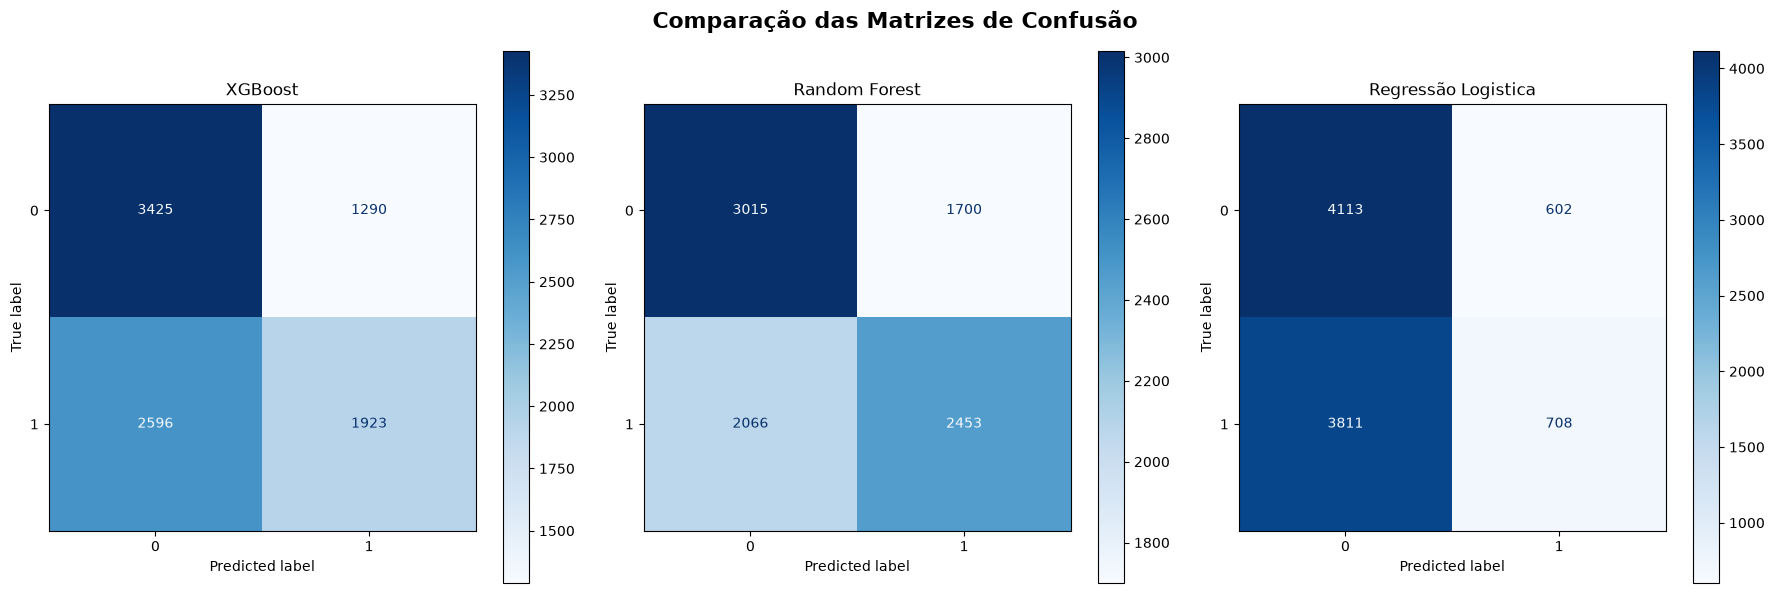

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# XGBoost
ConfusionMatrixDisplay.from_estimator(modelo_xgb_final, X_validacao_variance, y_validacao, cmap='Blues', ax=ax[0], colorbar=True)
ax[0].set_title("XGBoost")

# Random Forest
ConfusionMatrixDisplay.from_estimator(modelo_rf_final, X_validacao_variance, y_validacao, cmap='Blues', ax=ax[1], colorbar=True)
ax[1].set_title("Random Forest")

# KNN
ConfusionMatrixDisplay.from_estimator(modelo_rl_final, X_validacao_variance, y_validacao, cmap='Blues', ax=ax[2], colorbar=True)
ax[2].set_title("Regressão Logistica")

# Titulo geral
plt.suptitle("Comparação das Matrizes de Confusão", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 10.2 Análise das curvas ROC

A curva ROC avalia a capacidade dos modelos de distinguir entre as duas classes considerando diferentes thresholds de classificação.

O **Random Forest apresentou o maior ROC-AUC (0,63)**, seguido pelo **XGBoost (0,62)** e pela **Regressão Logística (0,56)**.

Os resultados indicam que Random Forest e XGBoost possuem maior capacidade discriminatória global, enquanto a Regressão Logística apresenta desempenho mais próximo de uma classificação aleatória.

Embora os valores de AUC sejam moderados, o Random Forest apresenta novamente o melhor equilíbrio geral, reforçando sua permanência como candidato ao modelo final.

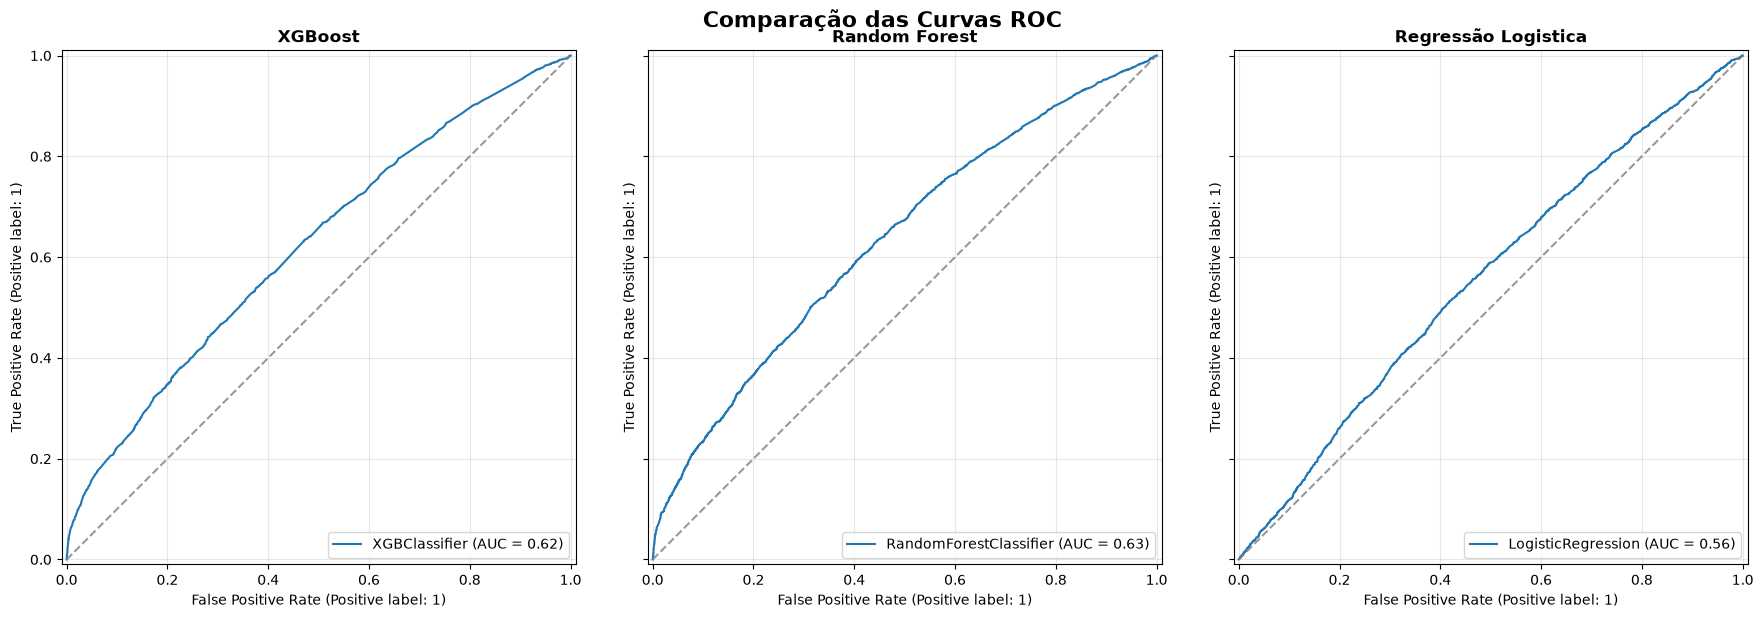

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# XGBoost
RocCurveDisplay.from_estimator(modelo_xgb_final, X_validacao_variance, y_validacao, ax=ax[0])
ax[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[0].set_title("XGBoost", fontweight="bold")
ax[0].grid(alpha=0.3)

# Random Forest
RocCurveDisplay.from_estimator(modelo_rf_final, X_validacao_variance, y_validacao, ax=ax[1])
ax[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[1].set_title("Random Forest", fontweight="bold")
ax[1].grid(alpha=0.3)

# KNN 
RocCurveDisplay.from_estimator(modelo_rl_final, X_validacao_variance, y_validacao, ax=ax[2])
ax[2].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[2].set_title("Regressão Logistica", fontweight="bold")
ax[2].grid(alpha=0.3)

plt.suptitle("Comparação das Curvas ROC", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

# 11. Ensemble com Voting Classifier

Foi construído um `VotingClassifier` combinando os modelos **Random Forest** e **XGBoost**.

Foi utilizada a estratégia `soft voting`, na qual as probabilidades previstas pelos modelos são combinadas para gerar a classificação final.

O objetivo é verificar se a combinação entre os dois modelos consegue melhorar a capacidade de generalização e o desempenho na identificação da classe prioritária.

In [29]:
modelo_voting = VotingClassifier(
    estimators=[
        ("random_forest", modelo_rf_final),
        ("xgboost", modelo_xgb_final)
    ],
    voting="soft",
    n_jobs=-1
)

In [30]:
modelo_voting.fit(X_treino_variance, y_treino)

pred_voting = modelo_voting.predict(X_validacao_variance)

In [31]:
print("Modelo Voting:")
print(classification_report(y_validacao, pred_voting))

Modelo Voting:
              precision    recall  f1-score   support

           0       0.58      0.68      0.63      4715
           1       0.60      0.49      0.54      4519

    accuracy                           0.59      9234
   macro avg       0.59      0.59      0.58      9234
weighted avg       0.59      0.59      0.58      9234



### 11.1 Análise do Voting Classifier

O Voting Classifier apresentou **Recall de 0,68 para a classe 0**, identificando 3.221 dos 4.715 alunos não alfabetizados presentes no conjunto de validação.

Por outro lado, o Recall da classe alfabetizada ficou em **0,49**, indicando maior concentração das previsões na classe prioritária.

O modelo apresentou **ROC-AUC de 0,63**, desempenho semelhante ao Random Forest individual.

Assim, o ensemble aumentou a sensibilidade para os alunos não alfabetizados, porém não apresentou ganho expressivo na capacidade discriminatória geral quando comparado ao Random Forest.

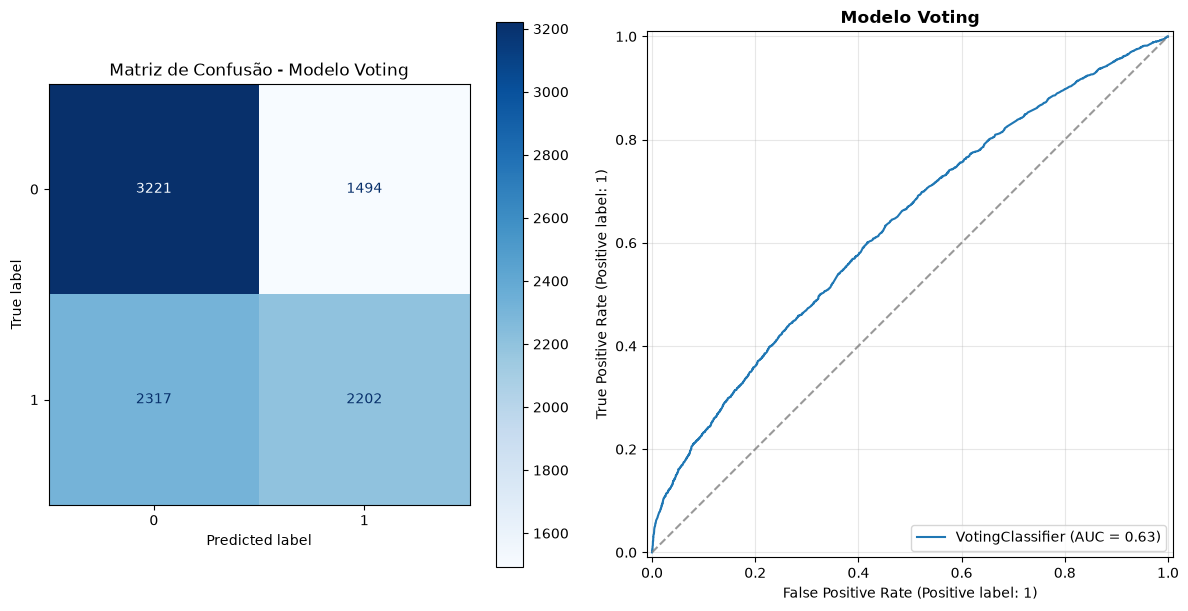

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Matriz de Confusão
ConfusionMatrixDisplay.from_estimator(modelo_voting, X_validacao_variance, y_validacao, cmap='Blues', ax=ax[0])
ax[0].set_title("Matriz de Confusão - Modelo Voting")

# Curva ROC
RocCurveDisplay.from_estimator(modelo_voting, X_validacao_variance, y_validacao, ax=ax[1])
ax[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[1].set_title("Modelo Voting", fontweight="bold")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 12. Ensemble com Stacking Classifier

Também foi avaliada uma estratégia de ensemble utilizando `StackingClassifier`.

O modelo combina **Random Forest** e **XGBoost** como estimadores base e utiliza uma **Regressão Logística** como meta-modelo responsável por combinar as probabilidades produzidas pelos classificadores.

Foi utilizada validação cruzada com 5 folds durante a construção do ensemble, buscando avaliar se a combinação entre diferentes modelos poderia melhorar o desempenho e a capacidade de generalização.

In [33]:
modelo_stacking = StackingClassifier(
    estimators=[
        ("random_forest", modelo_rf_final),
        ("xgboost", modelo_xgb_final)
    ],
    final_estimator=LogisticRegression(random_state=42, max_iter=3000),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1,
    passthrough=False
)

In [34]:
modelo_stacking.fit(X_treino_variance, y_treino)

pred_stacking = modelo_stacking.predict(X_validacao_variance)

proba_stacking = modelo_stacking.predict_proba(
    X_validacao_variance
)[:, 1]

### 12.1 Desempenho do Stacking Classifier

O Stacking apresentou desempenho relativamente equilibrado entre as duas classes.

O modelo alcançou **Recall de 0,62 para a classe 0** e **0,56 para a classe 1**, com acurácia próxima de **0,59**.

Os resultados indicam que o ensemble mantém capacidade razoável de identificação dos alunos não alfabetizados sem provocar uma queda acentuada no desempenho da classe alfabetizada.

In [35]:
print("Modelo Stacking")
print(classification_report(y_validacao, pred_stacking))

Modelo Stacking
              precision    recall  f1-score   support

           0       0.59      0.62      0.61      4715
           1       0.59      0.56      0.57      4519

    accuracy                           0.59      9234
   macro avg       0.59      0.59      0.59      9234
weighted avg       0.59      0.59      0.59      9234



### 12.2 Análise gráfica do Stacking Classifier

A matriz de confusão mostra que o Stacking identificou corretamente **2.923 alunos não alfabetizados** e **2.527 alunos alfabetizados**, apresentando uma distribuição de erros relativamente equilibrada entre as duas classes.

A curva ROC apresentou **AUC de aproximadamente 0,63**, indicando capacidade discriminatória semelhante à observada no Random Forest e no Voting Classifier.

De forma geral, o Stacking apresentou desempenho competitivo e equilibrado, porém sem ganho expressivo em relação ao Random Forest individual.

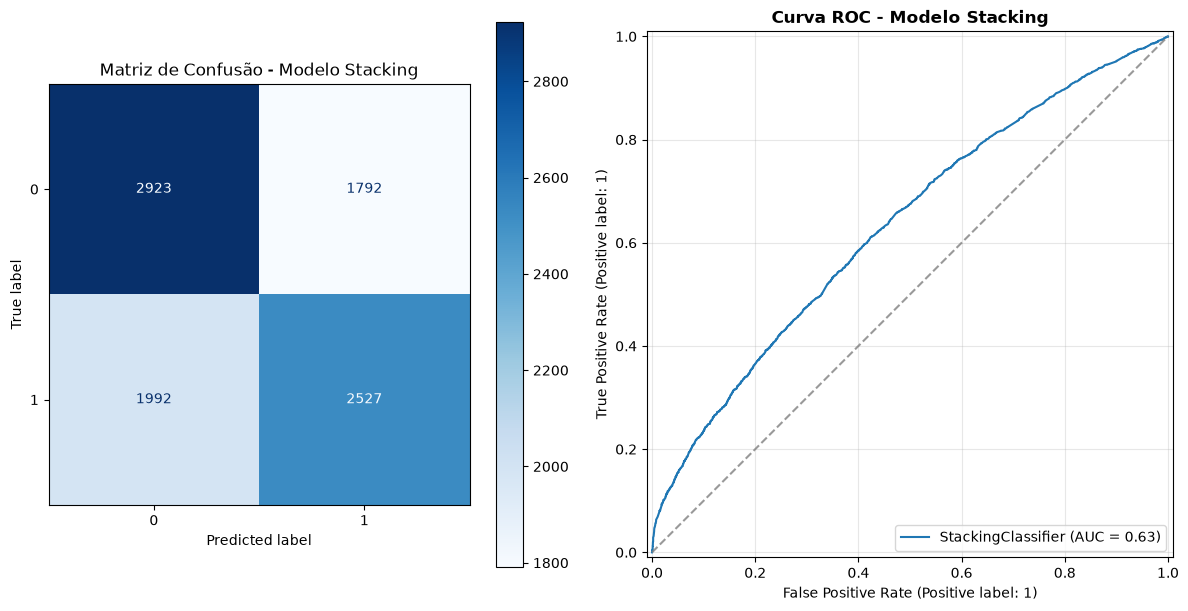

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Matriz de Confusão
ConfusionMatrixDisplay.from_estimator(modelo_stacking, X_validacao_variance, y_validacao, cmap='Blues', ax=ax[0])
ax[0].set_title("Matriz de Confusão - Modelo Stacking")

# Curva ROC
RocCurveDisplay.from_estimator(modelo_stacking, X_validacao_variance, y_validacao, ax=ax[1])
ax[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[1].set_title("Curva ROC - Modelo Stacking", fontweight="bold")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Comparação consolidada dos modelos

Após o tuning e os experimentos com ensembles, todos os modelos candidatos foram comparados utilizando as mesmas métricas no conjunto de validação.

Além do `Recall_0`, priorizado pelo objetivo do projeto, foram considerados o equilíbrio entre as classes, o `F1-Macro` e o `ROC-AUC` para apoiar a escolha do modelo final.

### 13.1 Seleção do modelo final

O **Random Forest Tunado** apresentou o melhor equilíbrio geral entre os modelos avaliados, com o maior **F1-Macro (0,5906)** e o maior **ROC-AUC (0,6337)**.

O Stacking apresentou desempenho muito próximo, porém sem ganho relevante em relação ao Random Forest individual.

Voting e XGBoost alcançaram maior `Recall_0`, mas com redução mais acentuada no desempenho da classe alfabetizada. Já a Regressão Logística apresentou o maior `Recall_0`, porém com forte desequilíbrio entre as classes.

Dessa forma, o **Random Forest Tunado foi selecionado como modelo final**, por apresentar melhor compromisso entre identificação dos alunos não alfabetizados, equilíbrio entre as classes e capacidade geral de discriminação.

In [37]:
modelos_comparacao = {
    "XGBoost Tunado": random_xgb.best_estimator_,
    "Random Forest Tunado": random_rf.best_estimator_,
    "Regressão Logística Tunada": random_rl.best_estimator_,
    "Voting": modelo_voting,
    "Stacking": modelo_stacking
}

resultados_comparacao = []

for nome, modelo in modelos_comparacao.items():
    
    pred = modelo.predict(X_validacao_variance)
    proba = modelo.predict_proba(X_validacao_variance)[:, 1]
    
    resultados_comparacao.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_validacao, pred),
        "Recall_0": recall_score(y_validacao, pred, pos_label=0),
        "Recall_1": recall_score(y_validacao, pred, pos_label=1),
        "Precision_0": precision_score(y_validacao, pred, pos_label=0),
        "Precision_1": precision_score(y_validacao, pred, pos_label=1),
        "F1_0": f1_score(y_validacao, pred, pos_label=0),
        "F1_1": f1_score(y_validacao, pred, pos_label=1),
        "F1_Macro": f1_score(y_validacao, pred, average="macro"),
        "ROC_AUC": roc_auc_score(y_validacao, proba)
    })

resultados_comparacao_df = (pd.DataFrame(resultados_comparacao).sort_values(by="F1_Macro", ascending=False).reset_index(drop=True))

resultados_comparacao_df.round(4)

,Modelo,Acurácia,Recall_0,Recall_1,Precision_0,Precision_1,F1_0,F1_1,F1_Macro,ROC_AUC
0,Random Forest Tunado,0.5922,0.6394,0.5428,0.5934,0.5907,0.6156,0.5657,0.5906,0.6337
1,Stacking,0.5902,0.6199,0.5592,0.5947,0.5851,0.6071,0.5718,0.5895,0.6323
2,Voting,0.5873,0.6831,0.4873,0.5816,0.5958,0.6283,0.5361,0.5822,0.6300
3,XGBoost Tunado,0.5792,0.7264,0.4255,0.5688,0.5985,0.6380,0.4974,0.5677,0.6199
4,Regressão Logística Tunada,0.5221,0.8723,0.1567,0.5191,0.5405,0.6508,0.2429,0.4469,0.5562


# 14. Análise do threshold de classificação

Após a seleção do Random Forest como modelo candidato final, foram avaliados diferentes thresholds de classificação utilizando o conjunto de validação.

Como o threshold é aplicado sobre a probabilidade da classe `1 — Alfabetizado`, seu aumento torna o modelo mais conservador para classificar um aluno como alfabetizado e, consequentemente, aumenta o `Recall_0`.

O objetivo desta análise é compreender o trade-off entre a identificação dos alunos não alfabetizados e a manutenção do desempenho da classe alfabetizada.

In [38]:
proba_rf = modelo_rf_final.predict_proba(X_validacao_variance)[:, 1]

### 14.1 Interpretação do trade-off

O threshold padrão de **0,50** apresentou o melhor equilíbrio geral entre as classes, com `Recall_0` de aproximadamente **0,64** e maior `F1-Macro`.

Ao aumentar o threshold, observa-se crescimento expressivo do `Recall_0`, porém acompanhado de forte redução do `Recall_1`.

Por exemplo, no threshold **0,55**, o modelo identifica aproximadamente **93% dos alunos não alfabetizados**, mas o Recall dos alfabetizados cai para cerca de **19%**.

Dessa forma, a escolha do threshold deve considerar o objetivo operacional do projeto. Como a prioridade é aumentar a identificação dos alunos não alfabetizados sem comprometer excessivamente a outra classe, será realizada uma análise mais refinada entre os thresholds de **0,50 e 0,55**.

In [39]:
thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

resultados_threshold = []

for threshold in thresholds:
    
    pred_threshold = (
        proba_rf >= threshold
    ).astype(int)
    
    resultados_threshold.append({
        "Threshold": threshold,
        
        "Acurácia": accuracy_score(y_validacao, pred_threshold),
                
        "Recall_0": recall_score(y_validacao, pred_threshold, pos_label=0),
        
        "Recall_1": recall_score(y_validacao, pred_threshold, pos_label=1),
        
        "Precision_0": precision_score(y_validacao, pred_threshold, pos_label=0),
        
        "Precision_1": precision_score(y_validacao, pred_threshold, pos_label=1),
        
        "F1_0": f1_score(y_validacao, pred_threshold, pos_label=0),
        
        "F1_1": f1_score(y_validacao, pred_threshold, pos_label=1),
        
        "F1_Macro": f1_score(y_validacao, pred_threshold, average="macro")
    })

df_threshold = pd.DataFrame(
    resultados_threshold
)

df_threshold.round(4)

,Threshold,Acurácia,Recall_0,Recall_1,Precision_0,Precision_1,F1_0,F1_1,F1_Macro
0,0.40,0.5330,0.1574,0.9250,0.6864,0.5127,0.2560,0.6597,0.4579
1,0.45,0.5696,0.3404,0.8088,0.6501,0.5403,0.4468,0.6478,0.5473
2,0.50,0.5922,0.6394,0.5428,0.5934,0.5907,0.6156,0.5657,0.5906
3,0.55,0.5690,0.9302,0.1921,0.5457,0.7251,0.6879,0.3037,0.4958
4,0.60,0.5417,0.9860,0.0781,0.5274,0.8425,0.6872,0.1430,0.4151
5,0.65,0.5363,0.9922,0.0606,0.5243,0.8810,0.6860,0.1135,0.3997
6,0.70,0.5297,0.9955,0.0436,0.5206,0.9037,0.6837,0.0832,0.3834


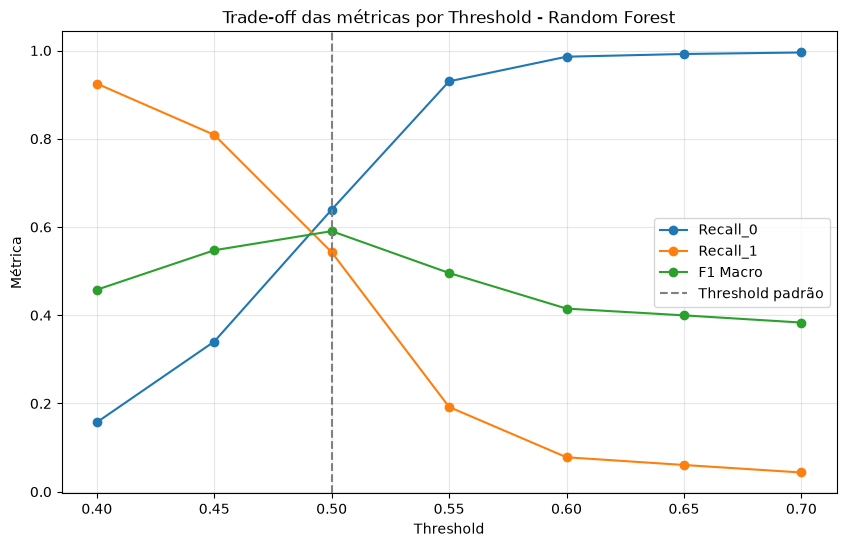

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(df_threshold["Threshold"], df_threshold["Recall_0"], marker="o", label="Recall_0")

plt.plot(df_threshold["Threshold"], df_threshold["Recall_1"], marker="o", label="Recall_1")


plt.plot(df_threshold["Threshold"], df_threshold["F1_Macro"], marker="o", label="F1 Macro")

plt.axvline(x=0.50, color="gray", linestyle="--", label="Threshold padrão")

plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.title("Trade-off das métricas por Threshold - Random Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 14.2 Seleção do threshold operacional

Considerando que o principal objetivo do projeto é apoiar a identificação de alunos potencialmente **não alfabetizados**, foi priorizado o `Recall_0`.

Na análise mais refinada, o threshold **0,52** elevou o Recall da classe 0 de aproximadamente **63,9% para 78,3%**, mantendo a acurácia próxima ao valor obtido com o threshold padrão.

Esse ganho ocorre em troca de uma redução no `Recall_1`, que passa de aproximadamente **54,3% para 38,7%**, evidenciando o trade-off entre maior sensibilidade para alunos não alfabetizados e menor capacidade de identificação da classe alfabetizada.

Dessa forma, o threshold **0,52** foi selecionado como limite operacional, considerando o modelo como uma ferramenta de **triagem e priorização** de alunos que podem demandar acompanhamento pedagógico adicional.

O threshold padrão de **0,50** permanece como referência para cenários em que o objetivo seja obter maior equilíbrio entre as duas classes.

In [41]:
thresholds = [0.50, 0.51, 0.52, 0.53, 0.54, 0.55]

resultados_threshold_fino  = []

for threshold in thresholds:
    
    pred_threshold = (
        proba_rf >= threshold
    ).astype(int)
    
    resultados_threshold_fino .append({
        "Threshold": threshold,
        
        "Acurácia": accuracy_score(y_validacao, pred_threshold),
                
        "Recall_0": recall_score(y_validacao, pred_threshold, pos_label=0),
        
        "Recall_1": recall_score(y_validacao, pred_threshold, pos_label=1),
        
        "Precision_0": precision_score(y_validacao, pred_threshold, pos_label=0),
        
        "Precision_1": precision_score(y_validacao, pred_threshold, pos_label=1),
        
        "F1_0": f1_score(y_validacao, pred_threshold, pos_label=0),
        
        "F1_1": f1_score(y_validacao, pred_threshold, pos_label=1),
        
        "F1_Macro": f1_score(y_validacao, pred_threshold, average="macro")
    })

df_threshold_fino = pd.DataFrame(
    resultados_threshold_fino 
)

df_threshold_fino.round(4)

,Threshold,Acurácia,Recall_0,Recall_1,Precision_0,Precision_1,F1_0,F1_1,F1_Macro
0,0.50,0.5922,0.6394,0.5428,0.5934,0.5907,0.6156,0.5657,0.5906
1,0.51,0.5888,0.7169,0.4552,0.5786,0.6064,0.6403,0.5200,0.5802
2,0.52,0.5891,0.7826,0.3873,0.5713,0.6306,0.6605,0.4798,0.5702
3,0.53,0.5826,0.8392,0.3149,0.5610,0.6525,0.6725,0.4248,0.5486
4,0.54,0.5765,0.8918,0.2474,0.5529,0.6867,0.6826,0.3638,0.5232
5,0.55,0.5690,0.9302,0.1921,0.5457,0.7251,0.6879,0.3037,0.4958


### Seleção do threshold operacional

Considerando que o principal objetivo do modelo é apoiar a identificação de alunos potencialmente não alfabetizados, foi priorizado o Recall da classe 0.

A análise dos thresholds demonstrou que o valor padrão de 0,50 apresenta o melhor equilíbrio geral entre as classes. Entretanto, o threshold de **0,52** proporcionou aumento relevante na capacidade de identificação dos alunos não alfabetizados, elevando o Recall da classe 0 de aproximadamente **63,9% para 78,3%**.

Esse ganho ocorreu com pequena redução da acurácia global e aumento do F1-score da classe 0, embora acompanhado de redução na capacidade de identificação da classe 1.

Dessa forma, o threshold de **0,52** foi selecionado como limiar operacional, considerando o modelo como uma ferramenta de triagem e priorização de alunos que podem demandar acompanhamento pedagógico adicional.

O threshold padrão de 0,50 permanece como referência para cenários em que se deseja maior equilíbrio entre as duas classes.

# 15. Validação cruzada do modelo final

Após a seleção do Random Forest, foi realizada uma validação cruzada estratificada com **5 folds** sobre o conjunto de treinamento.

O objetivo é verificar se o desempenho do modelo permanece consistente em diferentes divisões dos dados, reduzindo a dependência de uma única separação entre treino e validação.

Foram avaliadas as métricas de acurácia, Recall, F1-score e ROC-AUC para analisar tanto o desempenho geral quanto o comportamento em cada classe.

In [42]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metricas = {
    "accuracy": "accuracy",
    "recall_0": make_scorer(recall_score, pos_label=0),
    "recall_1": make_scorer(recall_score, pos_label=1),
    "f1_0": make_scorer(f1_score, pos_label=0),
    "f1_1": make_scorer(f1_score, pos_label=1),
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc"
}

cv_resultados = cross_validate(
    estimator=modelo_rf_final,
    X = X_treino_variance,
    y = y_treino,
    cv=cv,
    scoring=metricas,
    n_jobs=-1
)

### 15.1 Interpretação da validação cruzada

Os resultados apresentaram baixa variação entre os folds, indicando comportamento estável do Random Forest.

O modelo obteve `Recall_0` médio de aproximadamente **0,65**, `F1-Macro` de **0,59** e `ROC-AUC` de **0,63**, com baixos desvios padrão.

Isso indica que o desempenho não depende fortemente de uma única divisão dos dados e reforça a estabilidade do modelo.

> Nesta etapa, as métricas utilizam o threshold padrão de `0,50`. O threshold operacional de `0,52` será aplicado posteriormente na avaliação final.

In [43]:
cv_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Recall_0", "Recall_1", "F1_0", "F1_1", "F1_Macro", "ROC_AUC"],
    
    "Média": [
        cv_resultados["test_accuracy"].mean(),
        cv_resultados["test_recall_0"].mean(),
        cv_resultados["test_recall_1"].mean(),
        cv_resultados["test_f1_0"].mean(),
        cv_resultados["test_f1_1"].mean(),
        cv_resultados["test_f1_macro"].mean(),
        cv_resultados["test_roc_auc"].mean()
    ],
    
    "Desvio padrão": [
        cv_resultados["test_accuracy"].std(),
        cv_resultados["test_recall_0"].std(),
        cv_resultados["test_recall_1"].std(),
        cv_resultados["test_f1_0"].std(),
        cv_resultados["test_f1_1"].std(),
        cv_resultados["test_f1_macro"].std(),
        cv_resultados["test_roc_auc"].std()
    ]
})

cv_df.round(4)

,Métrica,Média,Desvio padrão
0,Accuracy,0.5901,0.0022
1,Recall_0,0.6514,0.0127
2,Recall_1,0.5261,0.0147
3,F1_0,0.6187,0.0046
4,F1_1,0.5567,0.0075
5,F1_Macro,0.5877,0.0026
6,ROC_AUC,0.6290,0.0043


# 16. Avaliação final no conjunto de teste

Após a seleção do Random Forest e a definição do threshold operacional de **0,52**, o modelo final foi avaliado no conjunto de teste, mantido isolado durante as etapas anteriores.

Essa avaliação representa a estimativa final da capacidade de generalização do modelo em dados não utilizados durante treinamento, tuning ou seleção do threshold.

In [44]:
threshold_final = 0.52

proba_teste = modelo_rf_final.predict_proba(X_teste_variance)[:, 1]

pred_teste_final = (proba_teste >= threshold_final).astype(int)

### 16.1 Resultado final do modelo

No conjunto de teste, o Random Forest alcançou **Recall de 0,78 para a classe 0**, identificando corretamente **4.616 dos 5.894 alunos não alfabetizados**.

Esse aumento de sensibilidade ocorre em troca de menor desempenho na classe alfabetizada, cujo Recall ficou em aproximadamente **0,37**, refletindo o trade-off assumido na escolha do threshold operacional.

A curva ROC apresentou **AUC de aproximadamente 0,62**, indicando capacidade discriminatória moderada e comportamento consistente com os resultados observados durante a validação.

Dessa forma, o modelo final é utilizado como uma ferramenta de **triagem e priorização de alunos potencialmente não alfabetizados**, e não como diagnóstico definitivo, permitindo direcionar avaliações e acompanhamento pedagógico para os casos considerados de maior risco.

In [45]:
print("Modelo Final - Threshold 0.52")
print(classification_report(y_teste, pred_teste_final))

Modelo Final - Threshold 0.52
              precision    recall  f1-score   support

           0       0.56      0.78      0.66      5894
           1       0.62      0.37      0.46      5649

    accuracy                           0.58     11543
   macro avg       0.59      0.58      0.56     11543
weighted avg       0.59      0.58      0.56     11543



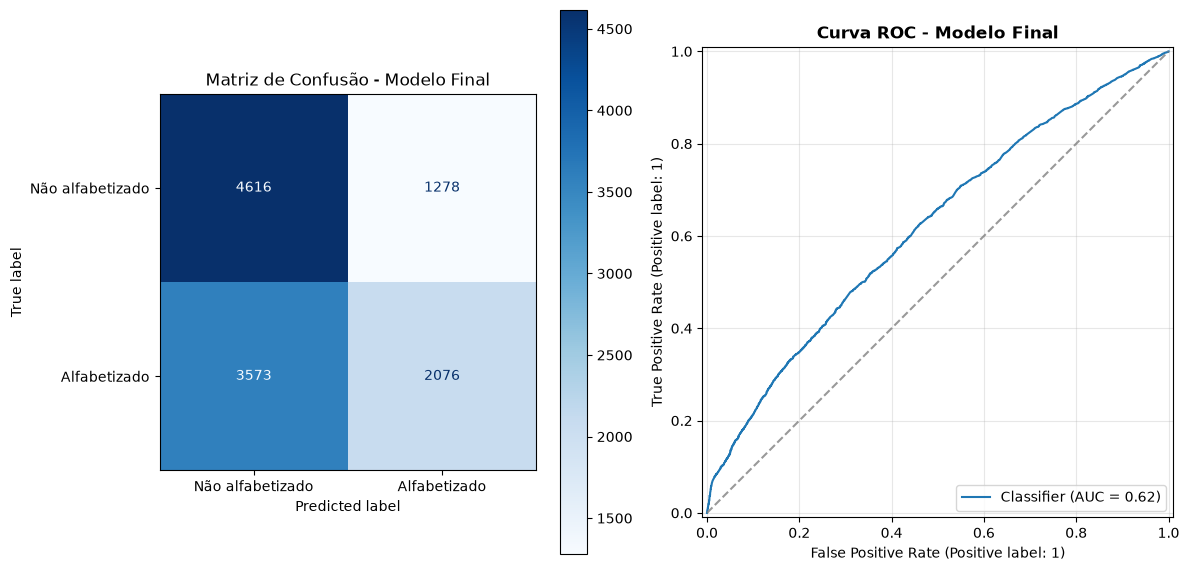

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Matriz de Confusão
ConfusionMatrixDisplay.from_predictions(y_teste, pred_teste_final, display_labels=["Não alfabetizado", "Alfabetizado"], cmap='Blues', ax=ax[0])
ax[0].set_title("Matriz de Confusão - Modelo Final")

# Curva Roc
RocCurveDisplay.from_predictions(y_teste, proba_teste, ax=ax[1])
ax[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[1].set_title("Curva ROC - Modelo Final", fontweight="bold")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 17. Feature Importance do modelo final

Após a avaliação do Random Forest, foi analisada a importância das variáveis utilizadas pelo modelo.

A `Feature Importance` permite identificar quais atributos tiveram maior participação nas decisões do Random Forest, ajudando a compreender quais características possuem maior relevância preditiva.

Para facilitar a análise, foram apresentadas as **10 features mais importantes** do modelo.

In [47]:
X_teste_variance_df = pd.DataFrame(
    X_teste_variance,
    columns=features_variance
)

In [48]:
importance_rf = pd.DataFrame({
    "feature": X_teste_variance_df.columns,
    "importance": modelo_rf_final.feature_importances_
})

importance_rf = importance_rf.sort_values("importance", ascending=False)
print(importance_rf.head(10))

                               feature  importance
23                         sigla_uf_CE    0.238970
22                         sigla_uf_BA    0.114158
5                    qtd_escolas_censo    0.057084
12  prop_escolas_internet_aprendizagem    0.054245
11               prop_escolas_internet    0.051593
4                densidade_demografica    0.039618
9      prop_escolas_biblioteca_leitura    0.038100
7            prop_escolas_agua_potavel    0.036578
2                       populacao_2022    0.035354
43                        regiao_Norte    0.033950


### 17.1 Interpretação das principais features

As variáveis com maior importância foram `sigla_uf_CE` e `sigla_uf_BA`, indicando forte participação do contexto territorial nas previsões do modelo.

Também aparecem entre as principais features indicadores relacionados à estrutura educacional, como quantidade de escolas, acesso à internet para aprendizagem, internet, biblioteca e água potável.

Variáveis populacionais e territoriais, como densidade demográfica, população e `regiao_Norte`, também apresentaram participação relevante.

Esses resultados reforçam a importância da combinação entre fatores territoriais e educacionais para a predição da alfabetização.

> A importância das features representa contribuição preditiva para o modelo e não deve ser interpretada como relação de causa e efeito.

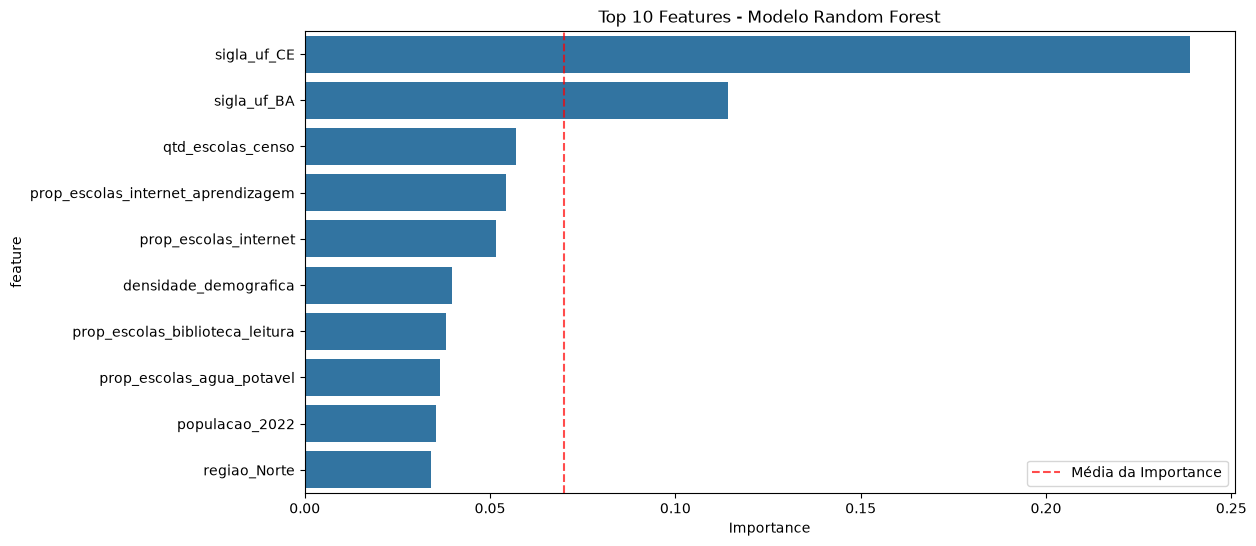

In [49]:
top_10_rf = importance_rf.head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top_10_rf['importance'], y=top_10_rf['feature'])
plt.axvline(top_10_rf['importance'].mean(), color='red', linestyle='--', alpha=0.7, label='Média da Importance')

plt.xlabel("Importance")
plt.title("Top 10 Features - Modelo Random Forest")
plt.legend()
plt.show()


# 18. Interpretabilidade do modelo com SHAP

Após a análise de importância das features do Random Forest, foi utilizado o **SHAP (SHapley Additive exPlanations)** para aprofundar a interpretação das previsões.

O SHAP permite analisar tanto a importância global das variáveis quanto a direção de suas contribuições em previsões individuais.

Como o objetivo principal do projeto é identificar alunos potencialmente **não alfabetizados**, as análises serão concentradas na **classe 0 — Não alfabetizado**.

### 18.1 Cálculo dos valores SHAP

Foi utilizado o `TreeExplainer`, apropriado para modelos baseados em árvores, para calcular os valores SHAP do Random Forest final.

Como o modelo possui duas classes, foram selecionados especificamente os valores referentes à **classe 0 — Não alfabetizado**, permitindo analisar quais features aumentam ou reduzem a saída do modelo para essa classe.

In [50]:
# Criando o explainer específico para o Random Forest
explainer = shap.TreeExplainer(modelo_rf_final)

# Calculando os valores SHAP para o conjunto de teste
shap_values = explainer.shap_values(X_teste_variance_df)

print("Shape X_teste:", X_teste_variance_df.shape)
print("Shape SHAP:", np.asarray(shap_values).shape)

Shape X_teste: (11543, 46)
Shape SHAP: (11543, 46, 2)


In [51]:
# Selecionando os valores SHAP referentes à classe 0
# Classe 0 = Não alfabetizado
shap_values_classe_0 = shap_values[:, :, 0]

print(f"Shape SHAP - Classe 0: {shap_values_classe_0.shape}")

Shape SHAP - Classe 0: (11543, 46)


### 18.2 Importância global das variáveis

O gráfico de importância global apresenta as features ordenadas pela média do valor absoluto de SHAP.

Quanto maior o valor, maior foi o impacto médio da variável nas previsões referentes à classe **Não alfabetizado**.

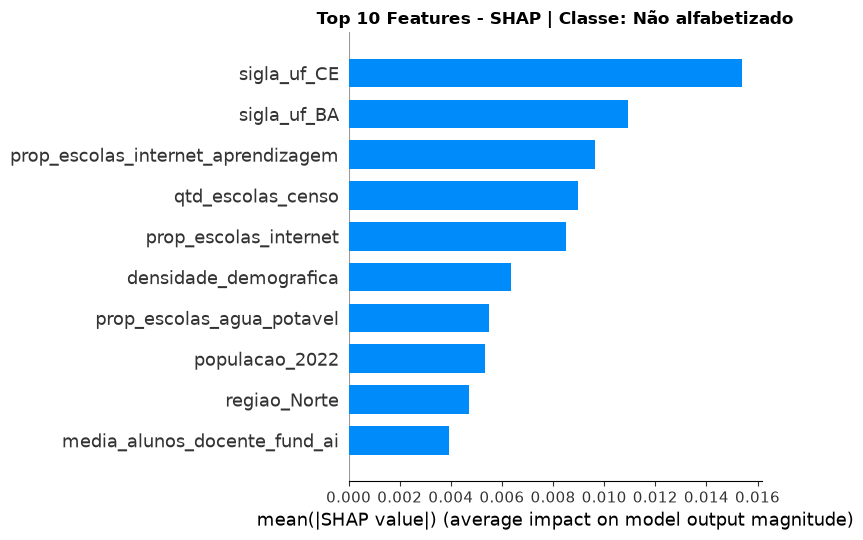

In [52]:
shap.summary_plot(
    shap_values_classe_0,
    X_teste_variance_df,
    max_display=10,
    plot_type="bar",
    show=False
)

plt.title("Top 10 Features - SHAP | Classe: Não alfabetizado", fontweight="bold")

plt.tight_layout()
plt.show()

As variáveis `sigla_uf_CE` e `sigla_uf_BA` apresentaram os maiores impactos globais, reforçando a relevância do contexto territorial observado anteriormente.

Também aparecem entre as principais variáveis indicadores relacionados à infraestrutura educacional, como internet para aprendizagem, quantidade de escolas, acesso à internet e água potável.

Os resultados são consistentes com a Feature Importance do Random Forest e reforçam que o modelo utiliza uma combinação de características territoriais, populacionais e educacionais.

> Os valores SHAP representam influência sobre a previsão do modelo e não devem ser interpretados como relações causais.

### 18.3 Distribuição e direção do impacto das features

Além da importância global, o SHAP permite analisar a **direção do impacto** de cada variável.

No gráfico, valores SHAP positivos aumentam a contribuição para a classe **Não alfabetizado**, enquanto valores negativos reduzem essa contribuição.

As cores representam os valores das features, permitindo observar como valores baixos e altos se relacionam com a saída do modelo.

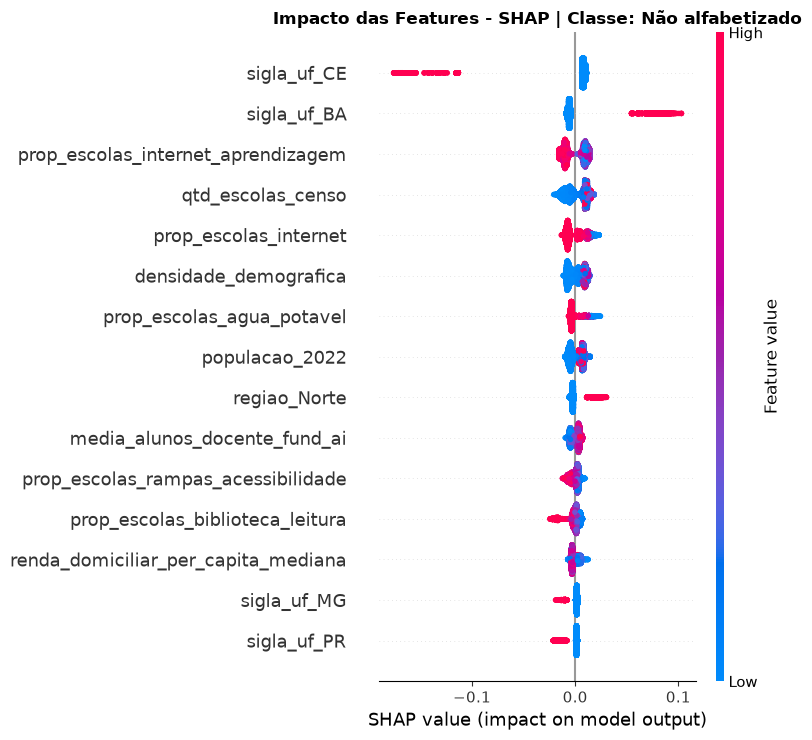

In [53]:
shap.summary_plot(
    shap_values_classe_0,
    X_teste_variance_df,
    max_display=15,
    show=False
)

plt.title("Impacto das Features - SHAP | Classe: Não alfabetizado", fontweight="bold")

plt.tight_layout()
plt.show()

O gráfico evidencia comportamentos territoriais distintos. A presença da categoria `sigla_uf_CE`, por exemplo, apresenta contribuição predominantemente negativa para a classe 0, enquanto `sigla_uf_BA` apresenta contribuições positivas em parte relevante dos registros.

Também é possível observar que maiores valores de alguns indicadores de infraestrutura, como acesso à internet e recursos educacionais, tendem a apresentar contribuição negativa para a previsão de não alfabetização.

Esses padrões representam o comportamento aprendido pelo modelo e devem ser interpretados em conjunto com o contexto dos dados.

### 18.4 Análise de dependência das principais variáveis

O `Dependence Plot` foi utilizado para analisar com maior detalhe a relação entre uma feature específica e sua contribuição para a previsão da classe 0.

Nesta análise foi selecionada a variável `prop_escolas_internet_aprendizagem`, que apareceu entre as features mais relevantes nas análises anteriores.

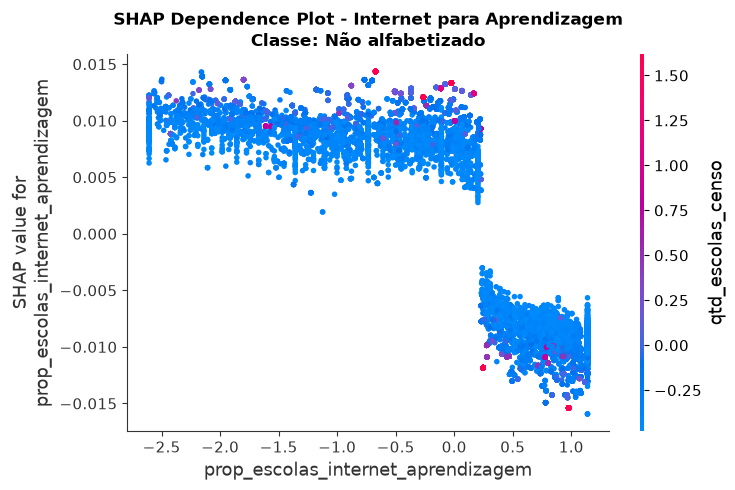

In [54]:
feature_dependence = "prop_escolas_internet_aprendizagem"

shap.dependence_plot(
    feature_dependence,
    shap_values_classe_0,
    X_teste_variance_df,
    interaction_index="auto",
    show=False
)

plt.title(
    "SHAP Dependence Plot - Internet para Aprendizagem\n"
    "Classe: Não alfabetizado",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

O gráfico indica uma tendência de redução dos valores SHAP à medida que aumenta a disponibilidade de internet voltada à aprendizagem.

Isso sugere que, dentro do comportamento aprendido pelo modelo, contextos com maior disponibilidade desse recurso tendem a contribuir menos para a previsão da classe **Não alfabetizado**.

Como as variáveis numéricas foram padronizadas durante o pré-processamento, os valores apresentados no eixo horizontal estão na escala transformada pelo `StandardScaler`, e não na escala percentual original.

A relação observada é preditiva e não representa evidência de causalidade.

### 18.5 Explicação individual de uma previsão

Além das análises globais, o SHAP permite explicar uma previsão individual.

Foi selecionado um aluno do conjunto de teste cuja classe real e prevista correspondem a **Não alfabetizado**.

O gráfico Waterfall mostra como cada feature contribuiu positiva ou negativamente para a saída do Random Forest referente à classe 0.

In [55]:
target_descriptions = {
    0: "Não Alfabetizado",
    1: "Alfabetizado"
}

indice_aluno = 3

aluno_df = X_teste_variance_df.iloc[[indice_aluno]]

classe_real = y_teste.iloc[indice_aluno]

classe_prevista = modelo_rf_final.predict(aluno_df)[0]

probabilidades = modelo_rf_final.predict_proba(aluno_df)[0]

print(
    f"Classe Real : {classe_real} - "
    f"{target_descriptions[classe_real]}"
)

print(
    f"Classe Prevista: {classe_prevista} - "
    f"{target_descriptions[classe_prevista]}"
)

print(
    f"Probabilidades: {probabilidades}"
)

Classe Real : 0 - Não Alfabetizado
Classe Prevista: 0 - Não Alfabetizado
Probabilidades: [0.57631006 0.42368994]


c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\tech-challenge-fase3-literacy-ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\tech-challenge-fase3-literacy-ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


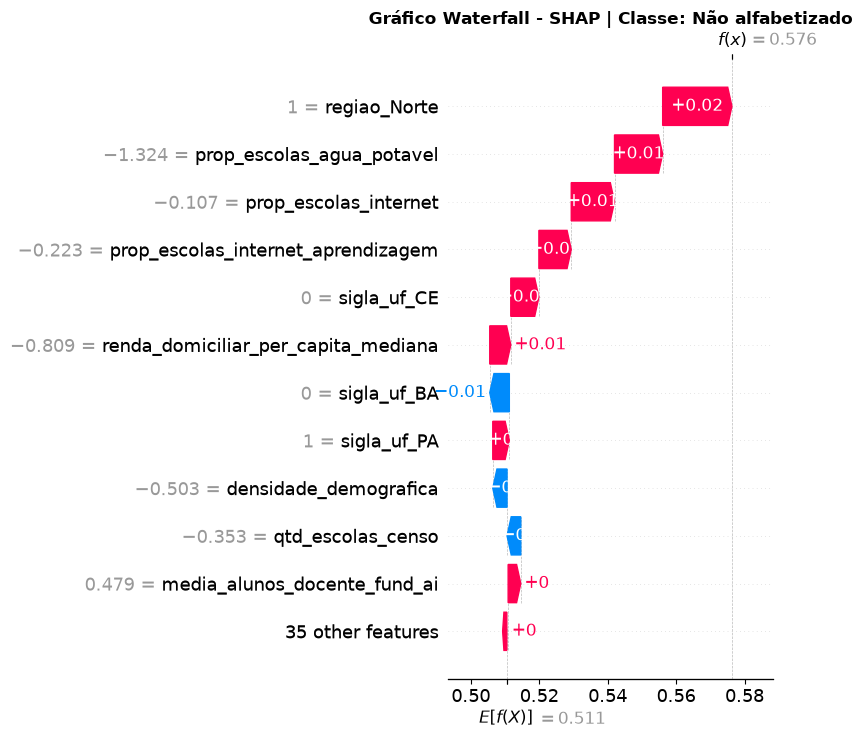

In [56]:
# Visualizando gráfico de Waterfall
explanation_cliente = shap.Explanation(
    values=shap_values_classe_0[indice_aluno],
    base_values=np.asarray(explainer.expected_value)[0],
    data=aluno_df.iloc[0].values,
    feature_names=aluno_df.columns.tolist()
)

shap.plots.waterfall(
    explanation_cliente,
    max_display=12,
    show=False
)

plt.title(
    "Gráfico Waterfall - SHAP | Classe: Não alfabetizado",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Para o registro analisado, o modelo atribuiu aproximadamente **57,6% de probabilidade à classe Não alfabetizado**.

O gráfico mostra que características como `regiao_Norte` e alguns indicadores de infraestrutura contribuíram para aumentar a saída do modelo para a classe 0, enquanto outras características exerceram efeito contrário.

Essa análise demonstra como o SHAP pode aumentar a transparência do modelo, permitindo compreender quais fatores tiveram maior influência em uma previsão específica.

### 18.6 Síntese da análise SHAP

As análises com SHAP reforçam que as previsões do Random Forest são influenciadas principalmente pela combinação entre características **territoriais, educacionais, populacionais e socioeconômicas**.

A técnica permitiu complementar a Feature Importance ao mostrar não apenas quais variáveis são relevantes, mas também a direção de suas contribuições e seu impacto em previsões individuais.

Esses resultados aumentam a interpretabilidade da solução e tornam o modelo mais adequado para utilização como ferramenta de apoio à decisão.

# 19. Diagnóstico de overfitting com Learning Curve

Para avaliar possíveis sinais de overfitting, foi construída uma **Learning Curve** utilizando o Recall da classe 0, correspondente aos alunos não alfabetizados.

A curva compara o desempenho de treino e validação à medida que aumenta a quantidade de dados utilizados no treinamento.

Quanto menor a diferença entre as duas curvas ao final do processo, menor o indício de sobreajuste do modelo.

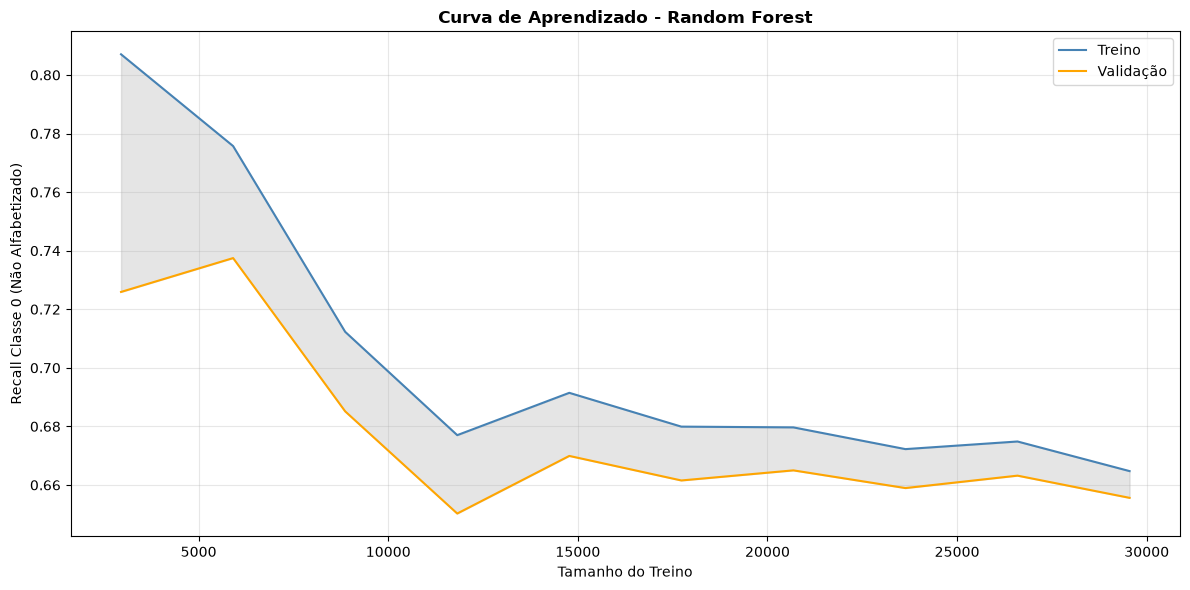

In [57]:
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=modelo_rf_final,
    X=X_treino_variance,
    y=y_treino,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring=score_recall_0,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(12,6))
plt.plot(train_sizes, train_mean, label='Treino', color='steelblue')
plt.plot(train_sizes, val_mean, label='Validação', color='orange')
plt.fill_between(train_sizes, train_mean, val_mean, alpha=0.2, color='gray')
plt.title("Curva de Aprendizado - Random Forest", fontweight='bold')
plt.xlabel("Tamanho do Treino")
plt.ylabel("Recall Classe 0 (Não Alfabetizado)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 19.1 Conclusão da Learning Curve

À medida que o volume de dados aumenta, as curvas de treino e validação se aproximam e apresentam comportamento estável.

Ao final da curva, o Random Forest obteve:

- **Recall_0 no treino:** 0,6647
- **Recall_0 na validação:** 0,6556
- **Gap treino-validação:** 0,0091

O pequeno gap indica **baixo indício de overfitting**, pois o desempenho do modelo permanece bastante semelhante entre treino e validação.

A estabilização das curvas também sugere que o Random Forest apresenta comportamento consistente para a identificação dos alunos não alfabetizados, reforçando sua capacidade de generalização.

In [58]:
gap_final = train_mean[-1] - val_mean[-1]

print(f"Recall Classe 0 final - Treino:    {train_mean[-1]:.4f}")
print(f"Recall Classe 0 final - Validação: {val_mean[-1]:.4f}")
print(f"Gap final:                  {gap_final:.4f}")

Recall Classe 0 final - Treino:    0.6647
Recall Classe 0 final - Validação: 0.6556
Gap final:                  0.0091


# 20. Aplicação prática do modelo

Após a avaliação e interpretação do modelo final, as probabilidades geradas pelo Random Forest serão utilizadas para criar um **score de risco de não alfabetização**.

O objetivo é transformar a saída do modelo em uma informação útil para apoio à decisão, permitindo posteriormente identificar alunos prioritários e analisar a concentração de risco por município e região.

A partir desta etapa, serão utilizadas consultas SQL com `DuckDB` para relacionar as previsões aos dados dos alunos e gerar as análises de negócio.

## 20.1 Preparação dos dados para análise

A base utilizada na análise exploratória é carregada novamente para recuperar informações de identificação e contexto dos alunos que não foram utilizadas como preditores durante o treinamento.

In [59]:
df_eda = pd.read_parquet("../data/gold/dataset_eda.parquet")
df_eda.head()

,ano,id_municipio,id_municipio_nome,id_escola,id_aluno,caderno,rede,presenca,preenchimento_caderno,alfabetizado,...,prop_escolas_lab_informatica,prop_escolas_internet,prop_escolas_internet_aprendizagem,prop_escolas_banda_larga,prop_escolas_rampas_acessibilidade,media_alunos_turma_fund_ai,media_alunos_docente_fund_ai,media_prop_salas_climatizadas,renda_domiciliar_per_capita_mediana,alfabetizado_bin
0,2023,1302504,Manacapuru,60000951,13015851,1,Municipal,Ausente,Prova não preenchida,Não,...,0.029412,0.705882,0.411765,0.541667,0.308824,19.188693,16.360779,0.642714,460.00,0
1,2023,1302603,Manaus,60000963,13030738,1,Municipal,Ausente,Prova não preenchida,Não,...,0.529058,0.969940,0.665331,0.878099,0.492986,25.931574,28.238906,0.920097,686.00,0
2,2023,1300631,Beruri,60001351,13003982,1,Municipal,Ausente,Prova não preenchida,Não,...,0.000000,0.292135,0.224719,0.884615,0.056180,15.716064,14.607079,0.088443,347.67,0
3,2023,1711506,Jaú do Tocantins,60004115,17012510,1,Municipal,Ausente,Prova não preenchida,Não,...,0.200000,1.000000,0.200000,0.400000,0.600000,17.472222,17.472222,0.200000,850.00,0
4,2023,2100709,Anajatuba,60004434,21012344,1,Municipal,Ausente,Prova não preenchida,Não,...,0.000000,0.948718,0.179487,1.000000,0.384615,25.611508,16.573413,0.198077,500.00,0


In [60]:
prob_risco = modelo_rf_final.predict_proba(X_teste_variance)[:, 0]

O score corresponde à probabilidade estimada pelo modelo de o registro pertencer à **classe 0 — Não alfabetizado**, apresentada em escala percentual para facilitar sua interpretação.

In [61]:
df_predicoes = pd.DataFrame({
    "indice_original": y_teste.index,
    "score_risco": (prob_risco * 100).round(2)
})

df_predicoes.head()

,indice_original,score_risco
0,45036,56.13
1,31162,43.44
2,49543,54.89
3,1196,57.63
4,6111,49.22


O índice original dos registros é preservado para permitir o relacionamento entre as previsões do conjunto de teste e as informações dos respectivos alunos por meio de consultas SQL.

In [62]:
df_alunos_sql = (df_eda.reset_index().rename(columns={"index": "indice_original"}))

In [63]:
duckdb.sql("""
    SELECT * FROM df_predicoes
    LIMIT 5
""").df()

,indice_original,score_risco
0,45036,56.13
1,31162,43.44
2,49543,54.89
3,1196,57.63
4,6111,49.22


## 20.2 Priorização dos alunos

O score de risco foi utilizado para transformar a probabilidade prevista pelo modelo em uma regra simples de priorização.

Como o threshold operacional de `0,52` foi definido para a classe **Alfabetizado**, o limite equivalente para a classe **Não alfabetizado** corresponde a aproximadamente **48%**.

Assim:

- score de risco acima de 48% → **Prioritário**;
- score de risco até 48% → **Monitoramento**.

Essa classificação permite criar uma fila de acompanhamento baseada no risco estimado pelo modelo.

In [64]:
df_risco = duckdb.sql("""
    SELECT
        a.id_aluno,
        a.id_municipio,
        a.id_municipio_nome,
        a.sigla_uf,
        a.regiao,
        a.rede,
        p.score_risco,

        CASE
            WHEN p.score_risco > 48 THEN 'Prioritário'
            ELSE 'Monitoramento'
        END AS prioridade

    FROM df_alunos_sql a
    JOIN df_predicoes p ON a.indice_original = p.indice_original
    ORDER BY p.score_risco DESC

""").df()

df_risco.head(10)

,id_aluno,id_municipio,id_municipio_nome,sigla_uf,regiao,rede,score_risco,prioridade
0,29041888,2924405,Pilão Arcado,BA,Nordeste,Municipal,72.48,Prioritário
1,29041861,2924405,Pilão Arcado,BA,Nordeste,Municipal,72.48,Prioritário
2,29041825,2924405,Pilão Arcado,BA,Nordeste,Municipal,72.48,Prioritário
3,29170949,2924405,Pilão Arcado,BA,Nordeste,Municipal,70.85,Prioritário
4,29012820,2902708,Barra,BA,Nordeste,Municipal,70.11,Prioritário
5,29012936,2902708,Barra,BA,Nordeste,Municipal,70.11,Prioritário
6,29012217,2902708,Barra,BA,Nordeste,Municipal,70.11,Prioritário
7,29043153,2930204,Sento Sé,BA,Nordeste,Municipal,69.72,Prioritário
8,29239580,2930204,Sento Sé,BA,Nordeste,Municipal,69.72,Prioritário
9,29037660,2907202,Casa Nova,BA,Nordeste,Municipal,69.02,Prioritário


In [65]:
duckdb.sql("""
    SELECT
        prioridade,
        COUNT(*) AS quantidade,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS percentual
    FROM df_risco
    GROUP BY prioridade
    ORDER BY quantidade DESC

""").df()

,prioridade,quantidade,percentual
0,Prioritário,8187,70.93
1,Monitoramento,3356,29.07


A aplicação da regra operacional classificou aproximadamente **70,9% dos registros como prioritários** e **29,1% como monitoramento**.

Esse resultado é coerente com a estratégia adotada no projeto, que prioriza maior sensibilidade na identificação de alunos potencialmente não alfabetizados.

## 20.3 Identificação dos casos de alto risco

Como uma parcela elevada dos alunos foi classificada como prioritária, foi criado um segundo nível de priorização para destacar os casos com maior score de risco.

O limite de **alto risco** foi definido pelo percentil 75 dos scores dos alunos já classificados como prioritários.

Essa estratégia permite diferenciar os casos mais críticos sem alterar o threshold operacional definido para o modelo.

In [66]:
limite_alto_risco = duckdb.sql("""
    SELECT
        quantile_cont(score_risco, 0.75) AS limite
    FROM df_risco
    WHERE prioridade = 'Prioritário'
""").df()["limite"].iloc[0]

print(f"Limite de alto risco: {limite_alto_risco:.2f}%")

Limite de alto risco: 56.86%


O percentil 75 resultou em um limite de aproximadamente **56,86%**.

Dessa forma, alunos prioritários com score igual ou superior a esse valor serão considerados casos de **alto risco**, permitindo uma priorização mais direcionada para ações de acompanhamento.

## 20.4 Identificação de municípios prioritários

Os scores dos alunos foram agregados por município para identificar localidades com maior concentração de casos classificados como **alto risco**.

Para reduzir distorções causadas por amostras muito pequenas, foram considerados apenas municípios com pelo menos **30 alunos** no conjunto analisado.

O percentual de alto risco representa a proporção de alunos cujo score ficou acima do limite definido anteriormente pelo percentil 75 dos casos prioritários.

In [67]:
risco_municipio = duckdb.sql(f"""
    SELECT
        id_municipio,
        id_municipio_nome,
        sigla_uf,

        COUNT(*) AS alunos,

        ROUND(
            AVG(score_risco),
            2
        ) AS score_medio,

        SUM(
            CASE
                WHEN score_risco >= {limite_alto_risco}
                    THEN 1
                ELSE 0
            END
        ) AS alunos_alto_risco,

        ROUND(
            SUM(
                CASE
                    WHEN score_risco >= {limite_alto_risco}
                        THEN 1
                    ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS pct_alto_risco

    FROM df_risco

    GROUP BY
        id_municipio,
        id_municipio_nome,
        sigla_uf

    HAVING COUNT(*) >= 30

    ORDER BY pct_alto_risco DESC
""").df()

risco_municipio.head(10)

,id_municipio,id_municipio_nome,sigla_uf,alunos,score_medio,alunos_alto_risco,pct_alto_risco
0,3301702,Duque de Caxias,RJ,42,57.94,42.0,100.00
1,2927408,Salvador,BA,96,62.88,96.0,100.00
2,3300456,Belford Roxo,RJ,32,59.23,32.0,100.00
3,3304904,São Gonçalo,RJ,40,59.50,40.0,100.00
4,3303500,Nova Iguaçu,RJ,44,60.18,44.0,100.00
5,1600303,Macapá,AP,50,60.80,50.0,100.00
6,1302603,Manaus,AM,179,61.73,179.0,100.00
7,2704302,Maceió,AL,42,58.98,38.0,90.48
8,2408102,Natal,RN,44,56.68,38.0,86.36
9,1501402,Belém,PA,58,58.60,39.0,67.24


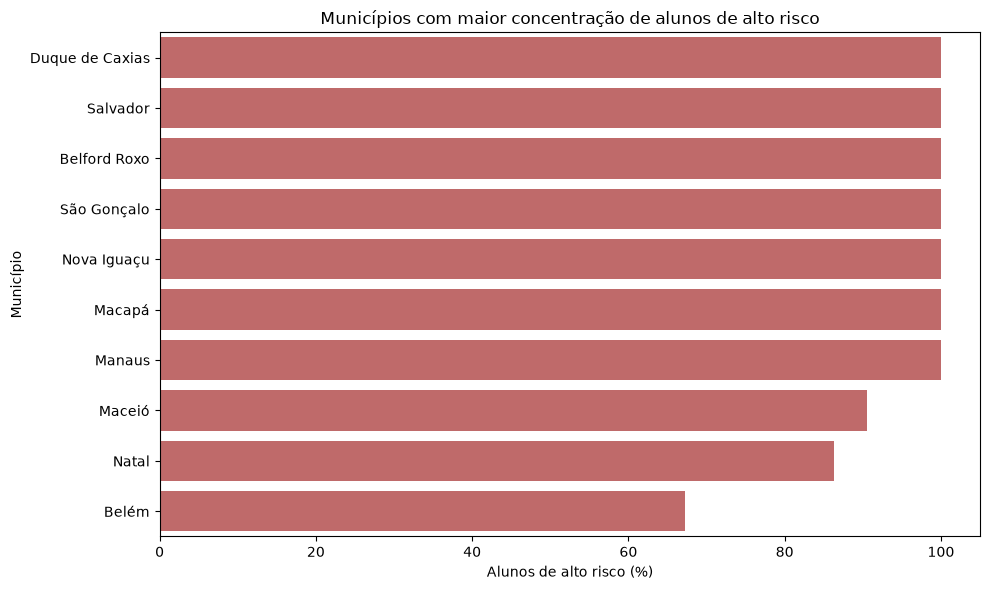

In [68]:
top_10 = risco_municipio.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10,
    x="pct_alto_risco",
    y="id_municipio_nome",
    color="indianred"
)

plt.title(
    "Municípios com maior concentração de alunos de alto risco"
)

plt.xlabel("Alunos de alto risco (%)")
plt.ylabel("Município")

plt.tight_layout()
plt.show()

#### Interpretação dos resultados

Os resultados mostram diferenças relevantes entre os municípios analisados, com algumas localidades apresentando elevada concentração de alunos classificados como alto risco.

Municípios como **Belford Roxo, São Gonçalo, Nova Iguaçu, Macapá e Manaus** aparecem entre os maiores percentuais observados na amostra.

Essa visão pode auxiliar gestores a identificar territórios que demandam maior atenção e priorizar ações de acompanhamento e alocação de recursos educacionais.

> Os percentuais representam classificações produzidas pelo modelo sobre a amostra analisada e não devem ser interpretados como taxas oficiais de alfabetização dos municípios.

## 20.5 Análise de risco por região

Além da análise municipal, os resultados foram agregados por região para identificar padrões territoriais mais amplos.

Foram considerados dois indicadores principais:

- **percentual de alunos de alto risco**, indicando a concentração dos casos mais críticos;
- **score médio de risco**, representando o nível médio de risco estimado pelo modelo em cada região.

Essa visão complementa a análise municipal e pode apoiar decisões de planejamento e priorização em nível regional.

In [69]:
risco_regiao = duckdb.sql(f"""
    SELECT
        regiao,

        COUNT(*) AS alunos,

        ROUND(
            AVG(score_risco),
            2
        ) AS score_medio,

        SUM(
            CASE
                WHEN prioridade = 'Prioritário'
                    THEN 1
                ELSE 0
            END
        ) AS prioritarios,

        ROUND(
            SUM(
                CASE
                    WHEN prioridade = 'Prioritário'
                        THEN 1
                    ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS pct_prioritarios,

        SUM(
            CASE
                WHEN score_risco >= {limite_alto_risco}
                    THEN 1
                ELSE 0
            END
        ) AS alunos_alto_risco,

        ROUND(
            SUM(
                CASE
                    WHEN score_risco >= {limite_alto_risco}
                        THEN 1
                    ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS pct_alto_risco

    FROM df_risco

    GROUP BY regiao

    ORDER BY pct_alto_risco DESC
""").df()

risco_regiao

,regiao,alunos,score_medio,prioritarios,pct_prioritarios,alunos_alto_risco,pct_alto_risco
0,Norte,1336,58.29,1329.0,99.48,877.0,65.64
1,Nordeste,3267,51.18,2559.0,78.33,962.0,29.45
2,Sudeste,3614,49.77,2366.0,65.47,202.0,5.59
3,Sul,2114,48.84,1097.0,51.89,8.0,0.38
4,Centro-Oeste,1212,50.30,836.0,68.98,1.0,0.08


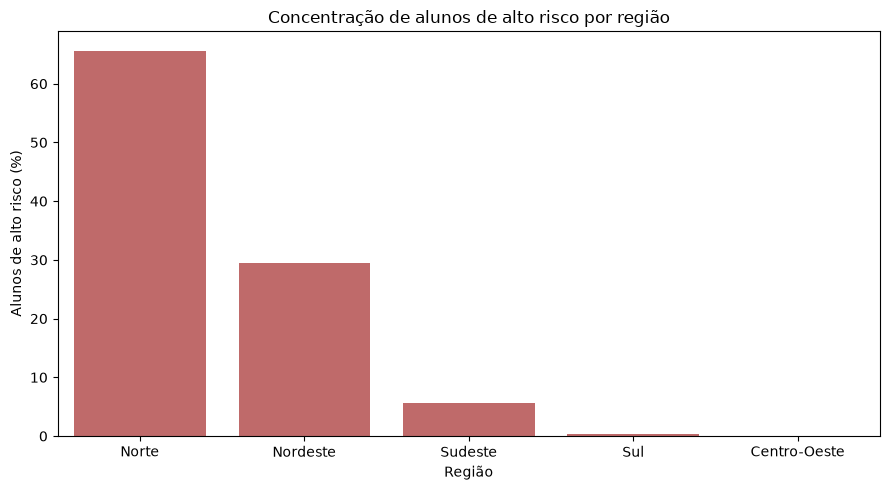

In [70]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=risco_regiao,
    x="regiao",
    y="pct_alto_risco",
    color="indianred"
)

plt.title(
    "Concentração de alunos de alto risco por região"
)

plt.xlabel("Região")
plt.ylabel("Alunos de alto risco (%)")

plt.tight_layout()
plt.show()

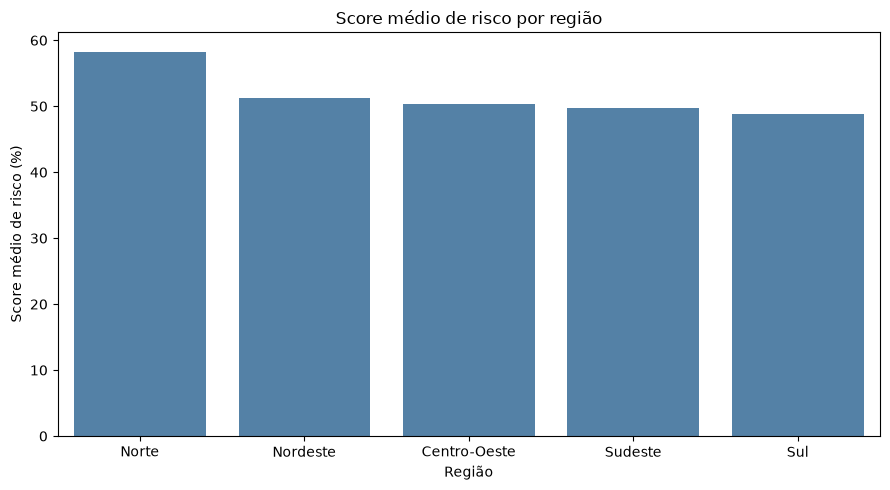

In [71]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=risco_regiao.sort_values(
        "score_medio",
        ascending=False
    ),
    x="regiao",
    y="score_medio",
    color="steelblue"
)

plt.title(
    "Score médio de risco por região"
)

plt.xlabel("Região")
plt.ylabel("Score médio de risco (%)")

plt.tight_layout()
plt.show()

#### Interpretação dos resultados

A região **Norte** apresentou o padrão de maior atenção, com score médio de aproximadamente **58,3%** e cerca de **65,6% dos registros classificados como alto risco**.

O **Nordeste** aparece em seguida, com aproximadamente **29,5% de alunos em alto risco**. Sudeste, Sul e Centro-Oeste apresentaram concentrações consideravelmente menores segundo o critério definido.

O segundo gráfico mostra que as diferenças no **score médio** entre as regiões são menos intensas do que as diferenças observadas no percentual de alto risco. Isso ocorre porque o indicador de alto risco utiliza um limite específico de **56,86%**, concentrando os registros que ultrapassam esse ponto.

Os resultados sugerem que a aplicação do modelo pode auxiliar na identificação de regiões que demandam maior atenção e apoiar o direcionamento de ações educacionais.

> Esses valores representam padrões estimados pelo modelo sobre os registros analisados e não devem ser interpretados como taxas oficiais de alfabetização das regiões.

# 21. Salvamento do modelo final

Para permitir a reutilização do modelo em novas previsões, as etapas de pré-processamento, seleção de variáveis e o Random Forest final foram agrupadas em um único `Pipeline`.

Dessa forma, o artefato salvo concentra as principais etapas necessárias para reproduzir a inferência sobre novos dados.

In [72]:
full_pipeline = Pipeline(
    steps=[
        ("preprocessador", preprocessador),
        ("selector_variance", selector_variance),
        ("modelo_rf_final", modelo_rf_final)
    ]
)

In [73]:
joblib.dump(full_pipeline, "../models/modelo_final_random_forest.pkl")

['../models/modelo_final_random_forest.pkl']

## 21.1 Teste do pipeline salvo

Após o salvamento, o pipeline foi carregado novamente para verificar se o artefato consegue realizar previsões a partir dos dados originais, sem executar manualmente as etapas de pré-processamento.

Para o registro utilizado no teste, o modelo estimou aproximadamente:

- **56,13%** de probabilidade para `Não alfabetizado`;
- **43,87%** de probabilidade para `Alfabetizado`.

Aplicando o threshold operacional de **0,52** sobre a probabilidade da classe alfabetizada, o registro foi classificado como **classe 0 — Não alfabetizado**.

O teste confirma que o pipeline salvo pode ser reutilizado para realizar novas inferências, executando automaticamente o pré-processamento, a seleção de variáveis e a previsão do Random Forest.

In [74]:
pipeline_completo = joblib.load("../models/modelo_final_random_forest.pkl")

In [75]:
probabilidade = pipeline_completo.predict_proba(X_teste.head(1))[0]

prob_nao_alfabetizado = probabilidade[0]
prob_alfabetizado = probabilidade[1]

classe_prevista = (
    1 if prob_alfabetizado >= 0.52 else 0
)

print(f"Prob. Não alfabetizado: {prob_nao_alfabetizado:.4f}")
print(f"Prob. Alfabetizado: {prob_alfabetizado:.4f}")
print(f"Classe prevista: {classe_prevista}")

Prob. Não alfabetizado: 0.5613
Prob. Alfabetizado: 0.4387
Classe prevista: 0


c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\tech-challenge-fase3-literacy-ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but VarianceThreshold was fitted with feature names
  warnings.warn(


## 21.2 Exportando Dataset Streamlit

In [76]:
from pathlib import Path
CAMINHO_APP = Path("../data/app")

CAMINHO_APP.mkdir(
    parents=True,
    exist_ok=True,
)

In [81]:
dados_teste_app = X_teste.copy()

In [82]:
print(dados_teste_app.shape)

display(dados_teste_app.head())

(11543, 22)


,ano,rede,sigla_uf,regiao,pib_per_capita,populacao_2022,area_km2,densidade_demografica,qtd_escolas_censo,prop_escolas_rurais,...,prop_escolas_biblioteca_leitura,prop_escolas_lab_informatica,prop_escolas_internet,prop_escolas_internet_aprendizagem,prop_escolas_banda_larga,prop_escolas_rampas_acessibilidade,media_alunos_turma_fund_ai,media_alunos_docente_fund_ai,media_prop_salas_climatizadas,renda_domiciliar_per_capita_mediana
45036,2023,Municipal,MA,Nordeste,14297.32,114275,4361.606,26.20,214,0.696262,...,0.076433,0.038217,0.707006,0.216561,0.846847,0.394904,16.467413,9.992217,0.161392,502.4
31162,2023,Municipal,PR,Sul,30674.49,13245,204.564,64.75,5,0.000000,...,0.400000,0.400000,1.000000,1.000000,1.000000,1.000000,22.555556,15.509338,1.000000,1250.0
49543,2024,Municipal,MT,Centro-Oeste,67650.08,244911,4824.020,50.77,104,0.134615,...,0.329787,0.063830,0.978723,0.659574,0.826087,0.691489,24.650333,20.618000,0.950232,1212.5
1196,2024,Municipal,PA,Norte,59767.25,91306,2084.289,43.81,48,0.270833,...,0.477273,0.250000,0.931818,0.636364,0.926829,0.681818,27.496906,21.018457,0.551568,704.0
6111,2024,Municipal,RO,Norte,40165.61,19327,1758.465,10.99,9,0.555556,...,0.857143,0.428571,1.000000,0.571429,1.000000,1.000000,21.440058,19.810606,0.885714,875.0


In [83]:
dados_teste_app.to_parquet(CAMINHO_APP / "dados_teste.parquet", index=False)

## 22. Conclusão da modelagem

A etapa de Machine Learning foi concluída com a construção, comparação, validação e interpretação dos modelos desenvolvidos para identificação de alunos potencialmente **não alfabetizados**.

### Principais resultados

- **Modelo final:** Random Forest otimizado;
- **Classe prioritária:** `0 — Não alfabetizado`;
- **Threshold operacional:** `0,52`;
- **Recall da classe 0 no teste:** aproximadamente **78%**;
- **ROC-AUC no teste:** aproximadamente **0,62**;
- **Overfitting:** baixo indício, com pequeno gap entre treino e validação na Learning Curve.

### Validação e interpretabilidade

O modelo final foi analisado utilizando diferentes estratégias:

- validação cruzada estratificada;
- matriz de confusão e curva ROC;
- Feature Importance;
- SHAP para interpretação global e individual;
- Learning Curve para diagnóstico de overfitting.

As análises indicaram comportamento estável e reforçaram a importância de variáveis **territoriais, educacionais, populacionais e socioeconômicas** nas previsões.

### Aplicação prática

As probabilidades do modelo foram transformadas em um **score de risco**, permitindo:

- priorizar alunos para acompanhamento;
- identificar casos de maior risco;
- analisar municípios com maior concentração de casos prioritários;
- comparar padrões de risco entre regiões;
- apoiar o direcionamento de ações e recursos educacionais.

> O modelo deve ser utilizado como uma ferramenta de **triagem e apoio à decisão**, e não como diagnóstico definitivo da situação de alfabetização de um aluno.

### Resultado final

O projeto encerra a etapa de modelagem com um modelo **validado, interpretável e reutilizável**, integrado a um pipeline contendo pré-processamento, seleção de variáveis e o Random Forest final.

O pipeline foi salvo para permitir sua utilização em novas inferências sem a necessidade de executar novamente todas as etapas de preparação e treinamento.